# End-to-End Sales Forecasting & Demand Intelligence System

**Author:** Vishal Jaiswal
**Dataset:** Superstore Sales Dataset (Kaggle)

This notebook covers the full analysis behind the project: cleaning and exploring four years
of Superstore order data, decomposing and forecasting monthly sales, screening for anomalous
weeks, and grouping products into demand segments. Each task builds on the one before it, and
the reusable logic behind every chart and statistic lives in `src/` rather than in the
notebook itself — this notebook is where that logic gets applied and the results get
explained.

## Task 1 — Data Loading, Merging & Deep Exploration

Before anything gets modelled, the raw export needs to be trustworthy. This section loads the
Superstore line items, checks the data for the usual problems — missing values, duplicates,
inconsistent dates — engineers the calendar features later tasks depend on, and answers four
questions about the business using the data itself rather than assumptions.

### Setup

The project root is added to `sys.path` so `src` imports cleanly regardless of where Jupyter
was launched from, the shared plot style is applied, and the output folders are created if
they don't already exist.

In [1]:
import sys
from pathlib import Path

# Make the project root importable so `import src...` works from the notebook.
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from src.utils.paths import PROCESSED_DATA_DIR, ensure_directories
from src.data.loader import (
    load_superstore_sales,
    missing_value_summary,
    duplicate_summary,
    date_integrity_summary,
)
from src.features.time_features import add_time_features, add_fulfillment_time
from src.data.aggregate import build_sales_time_series
from src.features import exploration as ex
from src.models import time_series as ts
from src.models import evaluation as ev
from src.models import sarima
from src.models import prophet_forecaster as prophet_fc
from src.models import xgboost_forecaster as xgb_fc
from src.models import segment_forecasting as seg_fc
from src.data.aggregate import segment_monthly_series
from src.models import anomaly_detection as ad
from src.models import clustering as cl
from src.visualization.style import configure_plot_style, save_figure
from src.visualization import charts

configure_plot_style()
ensure_directories()

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

### 1.1 Load the data

The raw file stores dates as `DD/MM/YYYY`. That format is pinned explicitly during parsing
inside `load_superstore_sales` rather than left for pandas to guess — values like `08/11/2017`
are valid under both day-first and month-first readings, and a silent misparse there would
quietly corrupt every time-based aggregation downstream.

In [2]:
sales = load_superstore_sales()
print(f"Rows: {sales.shape[0]:,}  |  Columns: {sales.shape[1]}")
sales.head()

Rows: 9,800  |  Columns: 18


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,"90,036.00",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37


### 1.2 Data quality audit

Before drawing any conclusions, it's worth confirming the dataset is actually sound: the
right structure and types, no unexpected missing values, no duplicate records, and a
consistent order/ship timeline. Each check below is a small reusable function, so the same
audit can be rerun the moment the data is refreshed.

In [3]:
schema = pd.DataFrame({
    "dtype": sales.dtypes.astype(str),
    "non_null": sales.notna().sum(),
    "n_unique": sales.nunique(),
})
schema

,dtype,non_null,n_unique
Row ID,int64,9800,9800
Order ID,object,9800,4922
Order Date,datetime64[ns],9800,1230
Ship Date,datetime64[ns],9800,1326
Ship Mode,object,9800,4
Customer ID,object,9800,793
Customer Name,object,9800,793
Segment,object,9800,3
Country,object,9800,1
City,object,9800,529


In [4]:
missing_value_summary(sales)

,missing_count,missing_pct
Postal Code,11,0.11


In [5]:
duplicate_summary(sales)

fully_duplicated_rows    0
duplicate_Row ID         0
dtype: int64

In [6]:
date_integrity_summary(sales)

order_date_min          2015-01-03 00:00:00
order_date_max          2018-12-30 00:00:00
ship_date_min           2015-01-07 00:00:00
ship_date_max           2019-01-05 00:00:00
ship_before_order                         0
unparsed_order_dates                      0
unparsed_ship_dates                       0
dtype: object

The dataset holds up well. It covers 9,800 line items across 18 columns, running from
2015-01-03 to 2018-12-30 — four complete years, which is exactly the span the forecasting
tasks need. The only missing values sit in `Postal Code` (11 rows, about 0.1% of the data),
and every one of them belongs to a Vermont order — a known quirk of this dataset, since
Vermont ZIP codes start with a leading zero that gets dropped on import. `Postal Code` has no
role in the sales analysis, so those rows are left as they are rather than discarded over a
cosmetic gap. There are no fully duplicated rows and no repeated `Row ID`. `Order ID` does
repeat, but that's expected — a single order can contain several product line items — so it
was never meant to be a uniqueness key. Every date parsed cleanly, and no order shows a ship
date earlier than its order date, so the timeline holds together.

In [7]:
# Sales is the only analytical numeric column; the rest are identifiers or categoricals.
sales["Sales"].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
Sales,"9,800.00",230.77,626.65,0.44,17.25,54.49,210.61,"22,638.48"


`Sales` is strictly positive, with a minimum around $0.44 and a heavy right tail — the maximum
is roughly $22,638 against a median well below the mean. That skew points to a handful of
unusually large orders, which is worth keeping in mind once anomaly detection comes up later.

### 1.3 Time feature engineering

The next step is building the calendar features later tasks depend on — `Year`, `Month`,
`Week Number` (ISO), `Day of Week`, `Quarter`, and `Season` — along with `Fulfillment Days`
(Ship Date minus Order Date) to answer the delivery-time question.

**Season mapping.** Every order ships within the United States, so we use meteorological
Northern-Hemisphere seasons, which align to whole calendar months and therefore compose
cleanly with the monthly aggregations:

| Months | Season |
| --- | --- |
| Dec, Jan, Feb | Winter |
| Mar, Apr, May | Spring |
| Jun, Jul, Aug | Summer |
| Sep, Oct, Nov | Autumn |

In [8]:
sales = add_time_features(sales)
sales = add_fulfillment_time(sales)

feature_cols = ["Order Date", "Year", "Month", "Week Number", "Day of Week",
                "Quarter", "Season", "Fulfillment Days"]
sales[feature_cols].head()

,Order Date,Year,Month,Week Number,Day of Week,Quarter,Season,Fulfillment Days
0,2017-11-08,2017,11,45,Wednesday,4,Autumn,3
1,2017-11-08,2017,11,45,Wednesday,4,Autumn,3
2,2017-06-12,2017,6,24,Monday,2,Summer,4
3,2016-10-11,2016,10,41,Tuesday,4,Autumn,7
4,2016-10-11,2016,10,41,Tuesday,4,Autumn,7


In [9]:
# Sanity check: seasons should map every row and cover all four labels.
sales["Season"].value_counts().reindex(["Winter", "Spring", "Summer", "Autumn"])

Season
Winter    2045
Spring    2062
Summer    2081
Autumn    3612
Name: count, dtype: int64

### 1.4 Daily, weekly, and monthly aggregations

Later models need the line items rolled up to daily, weekly, and monthly totals, since
different tasks operate at different granularities. Resampling is used instead of a plain
group-by: it inserts zero-sales rows for periods with no orders, which keeps each series
continuous rather than silently skipping gaps.

One thing worth checking rather than assuming — aggregation should never lose revenue. The
three series ought to sum to the same grand total as the raw data, and that gets asserted
below, not just hoped for.

In [10]:
series = build_sales_time_series(sales)
daily, weekly, monthly = series["daily"], series["weekly"], series["monthly"]

raw_total = sales["Sales"].sum()
for name, frame in series.items():
    assert abs(frame["Sales"].sum() - raw_total) < 1e-6, f"{name} total drifted from raw"
    print(f"{name:>7}: {frame.shape[0]:>4} periods | total sales ${frame['Sales'].sum():,.2f}")

print(f"{'raw':>7}: {sales.shape[0]:>4} rows    | total sales ${raw_total:,.2f}")

  daily: 1458 periods | total sales $2,261,536.78
 weekly:  209 periods | total sales $2,261,536.78
monthly:   48 periods | total sales $2,261,536.78
    raw: 9800 rows    | total sales $2,261,536.78


In [11]:
monthly.head()

,Order Date,Sales,Order Lines
0,2015-01-01,"14,205.71",77
1,2015-02-01,"4,519.89",46
2,2015-03-01,"55,205.80",154
3,2015-04-01,"27,906.85",130
4,2015-05-01,"23,644.30",121


The totals match to the cent across all three granularities, so no revenue is lost in
aggregation. The enriched line-item table and the three series are saved to
`data/processed/`, so later sections can reload them without redoing this work.

In [12]:
sales.to_csv(PROCESSED_DATA_DIR / "sales_with_features.csv", index=False)
daily.to_csv(PROCESSED_DATA_DIR / "daily_sales.csv", index=False)
weekly.to_csv(PROCESSED_DATA_DIR / "weekly_sales.csv", index=False)
monthly.to_csv(PROCESSED_DATA_DIR / "monthly_sales.csv", index=False)
sorted(p.name for p in PROCESSED_DATA_DIR.glob("*.csv"))

['daily_sales.csv',
 'monthly_sales.csv',
 'sales_with_features.csv',
 'weekly_sales.csv']

### 1.5 Business questions

Four questions, each answered from the data and backed by a table and a saved chart. Nothing
below is stated without the evidence sitting right above it.

#### Q1 — Which product category generates the highest total revenue?

,Total Revenue,Revenue Share %
Category,,
Technology,"827,455.87",36.59
Furniture,"728,658.58",32.22
Office Supplies,"705,422.33",31.19


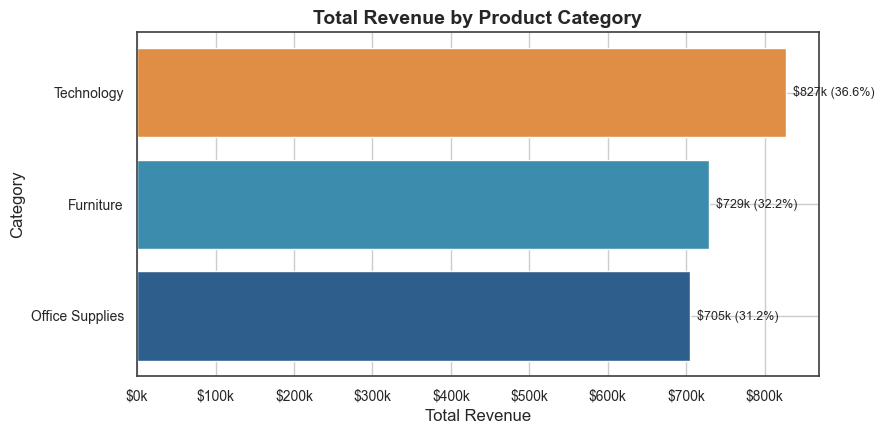

In [13]:
category_revenue = ex.revenue_by_category(sales)
save_figure(charts.plot_revenue_by_category(category_revenue), "revenue_by_category.png")
category_revenue

Technology leads with roughly $827k, or 36.6% of total revenue, ahead of Furniture (~$729k,
32.2%) and Office Supplies (~$705k, 31.2%). Revenue is fairly evenly split across the three
categories, but Technology is the clear top line despite usually having fewer line items than
Office Supplies — its higher average order value makes up the difference.

#### Q2 — Which region has the most consistent sales growth over four years?

Consistent growth means more than a high total — it means growing every year along a steady
path, not just ending higher than it started. Each region is scored on its average
year-over-year growth, the volatility of that growth, and the R² of a straight-line fit to its
annual sales, where a value closer to 1 signals a steadier trajectory.

In [14]:
yearly_region = ex.yearly_sales_by_region(sales)
yearly_region

Region,Central,East,South,West
Year,,,,
2015,"102,920.52","127,652.82","103,374.91","145,907.96"
2016,"102,425.17","153,225.18","70,076.08","133,709.57"
2017,"145,673.88","178,511.54","93,535.90","182,471.23"
2018,"141,627.34","210,129.19","122,164.57","248,130.93"


,Mean YoY Growth %,YoY Growth Std %,Trend R2,Grew Every Year
Region,,,,
East,18.08,1.46,1.00,True
West,21.36,21.02,0.80,False
Central,12.99,20.69,0.75,False
South,10.62,30.31,0.23,False


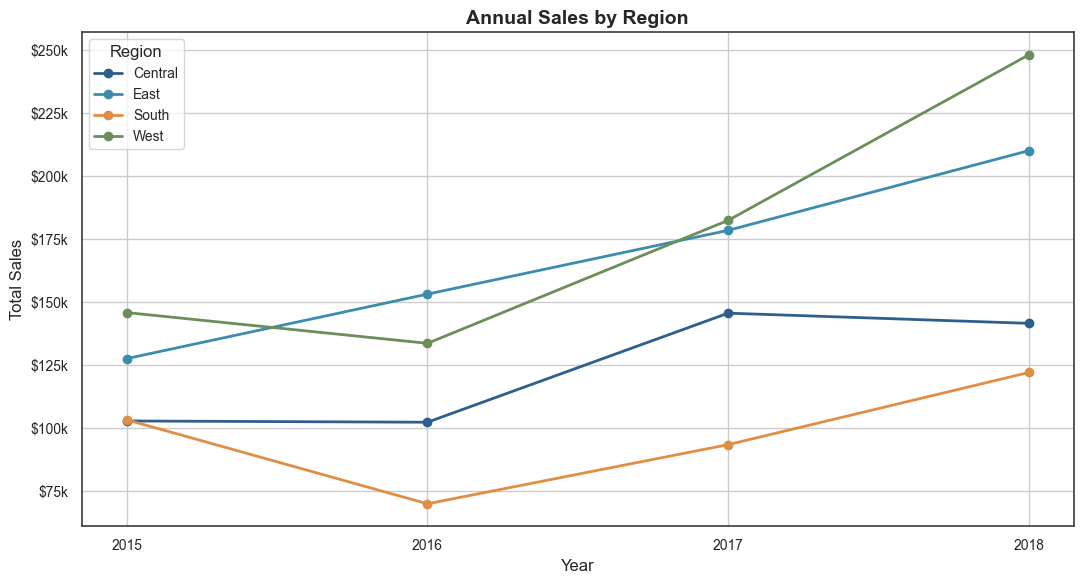

In [15]:
growth = ex.regional_growth_consistency(sales)
save_figure(charts.plot_yearly_sales_by_region(yearly_region), "annual_sales_by_region.png")
growth

East is the most consistent grower — the only region that increased every single year, and it
did so along a near-perfectly straight line (R² ≈ 0.997) with the lowest year-over-year
volatility of any region (growth std ≈ 1.5%). West actually grows faster on average, around
21% a year, but erratically — it dips in 2016 — and South is the most volatile of all four.
Neither comes close to East on consistency.

#### Q3 — What is the average time between Order Date and Ship Date, and does it vary by region?

Overall average fulfillment time: 3.96 days


,Mean Days,Median Days,Std Days,Order Lines
Region,,,,
East,3.91,4.00,1.73,2785
West,3.93,4.00,1.81,3140
South,3.96,4.00,1.74,1598
Central,4.07,4.00,1.69,2277


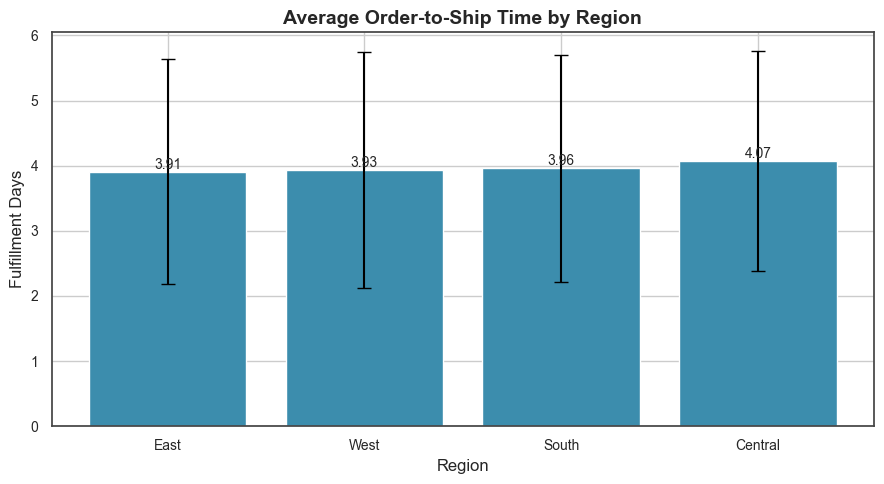

In [16]:
fulfillment = ex.fulfillment_time_by_region(sales)
save_figure(charts.plot_fulfillment_by_region(fulfillment), "fulfillment_days_by_region.png")

overall_days = sales["Fulfillment Days"].mean()
print(f"Overall average fulfillment time: {overall_days:.2f} days")
fulfillment

Orders ship in about 3.96 days on average, with a median of exactly 4 days. Regional variation
is negligible — East is fastest at 3.91 days, Central slowest at 4.07 — a spread of roughly
0.15 days, well inside each region's own day-to-day variation (a standard deviation of
1.7 to 1.8 days). Fulfillment speed is effectively uniform nationwide; it isn't something that
sets one region apart from another.

#### Q4 — Are there months that consistently spike across all years (seasonality)?

A spike in a single year doesn't prove seasonality. The more useful check is looking at
monthly sales across every year and counting how often each month lands in that year's top
three.

Year,2015,2016,2017,2018,Average
Month,,,,,
1,"14,205.71","18,066.96","18,542.49","43,476.47","23,572.91"
2,"4,519.89","11,951.41","22,978.82","19,921.00","14,842.78"
3,"55,205.80","32,339.32","51,165.06","58,863.41","49,393.40"
4,"27,906.86","34,154.47","38,679.77","35,541.91","34,070.75"
5,"23,644.30","29,959.53","56,656.91","43,825.98","38,521.68"
6,"34,322.94","23,599.37","39,724.49","48,190.73","36,459.38"
7,"33,781.54","28,608.26","38,320.78","44,825.10","36,383.92"
8,"27,117.54","36,818.34","30,542.20","62,837.85","39,328.98"
9,"81,623.53","63,133.61","69,193.39","86,152.89","75,025.86"


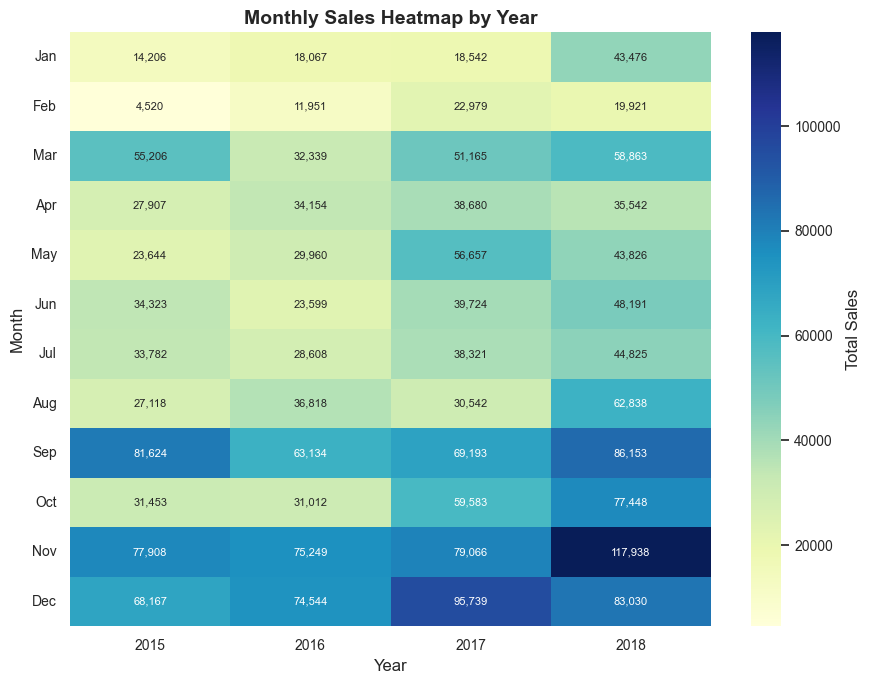

In [17]:
seasonality = ex.monthly_seasonality(sales)
save_figure(charts.plot_seasonality_heatmap(seasonality), "monthly_seasonality_heatmap.png")
seasonality

In [18]:
top_months = ex.consistently_strong_months(sales, top_n=3)
top_months.sort_values(ascending=False)

Month
9     4
11    4
12    4
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
10    0
Name: Years in Top 3, dtype: int64

Yes, and the pattern repeats reliably: September, November, and December rank in the top three
every single year, while January and February are consistently the weakest. It reads as a
second-half surge — a September back-to-school bump followed by the November-December holiday
peak — and it's visible as the dark band running down the right side of the heatmap. This is
the exact signal the forecasting models will need to pick up in the tasks ahead.

### Overall monthly sales trend

Pulling all of this together gives the headline view of the series that gets forecast later —
total sales per month across the four years. The gradual upward drift and the regular
year-end peaks are a preview of the trend and seasonal components that get formally separated
out in Task 2.

,Order Date,Sales,Order Lines
43,2018-08-01,"62,837.85",214
44,2018-09-01,"86,152.89",453
45,2018-10-01,"77,448.13",294
46,2018-11-01,"117,938.15",456
47,2018-12-01,"83,030.39",459


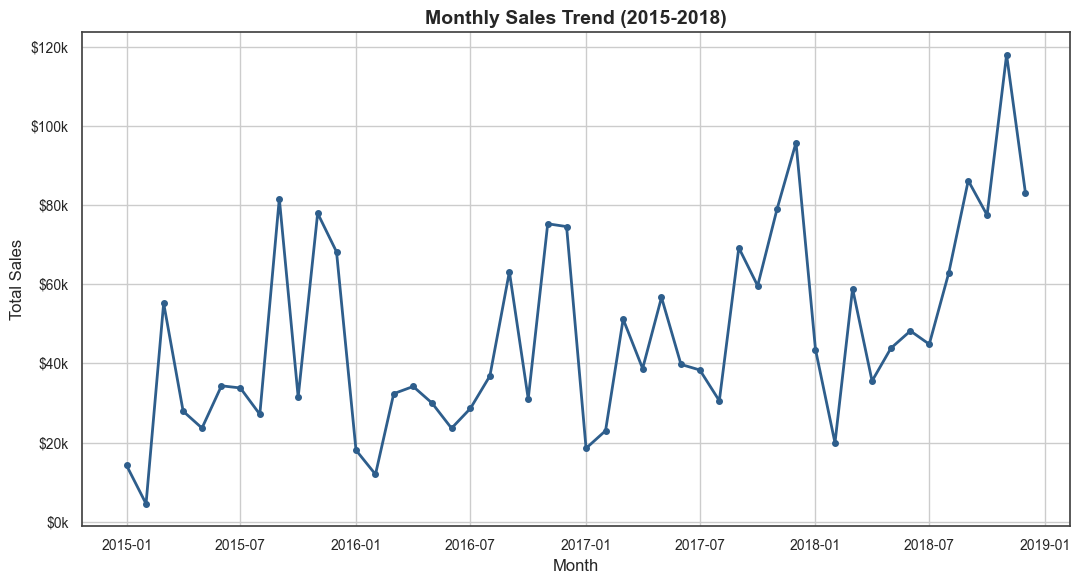

In [19]:
save_figure(charts.plot_monthly_sales_trend(monthly), "monthly_sales_trend.png")
monthly.tail()

Taken together, this section leaves a clear picture of the business going into the rest of
the analysis. The data itself is clean — four complete years, one cosmetic gap that doesn't
matter, no duplicates, a consistent order-to-ship timeline. Technology is the strongest
category by revenue, East is the region growing most reliably, fulfillment speed doesn't vary
meaningfully by geography, and demand is heavily seasonal, peaking every September, November,
and December. The daily, weekly, and monthly series built here carry every dollar of revenue
forward without loss, and they're what the rest of the notebook builds on.

## Task 2 — Time Series Analysis & Decomposition

With the data validated, the next step is understanding the shape of the series itself before
fitting anything to it. This section breaks the monthly sales series into its trend, seasonal,
and residual components, then tests formally whether it's stationary — a property the
statistical forecasting model in Task 3 depends on. The analysis runs on the 48-month series
built in Task 1, using an additive decomposition, a strength measure for each component, and
the Augmented Dickey-Fuller test for stationarity. Every statistic below comes from
`src/models/time_series.py`, so it can be reproduced or re-checked independently of this
notebook.

### 2.1 The monthly series and its trend

The monthly totals are reloaded through the module rather than reused from memory, so this
section stands on its own and can be rerun independently. Plotted out, the series shows a
mild upward drift sitting underneath a strong, regular annual cycle.

48 monthly observations from 2015-01 to 2018-12 (frequency: MS)


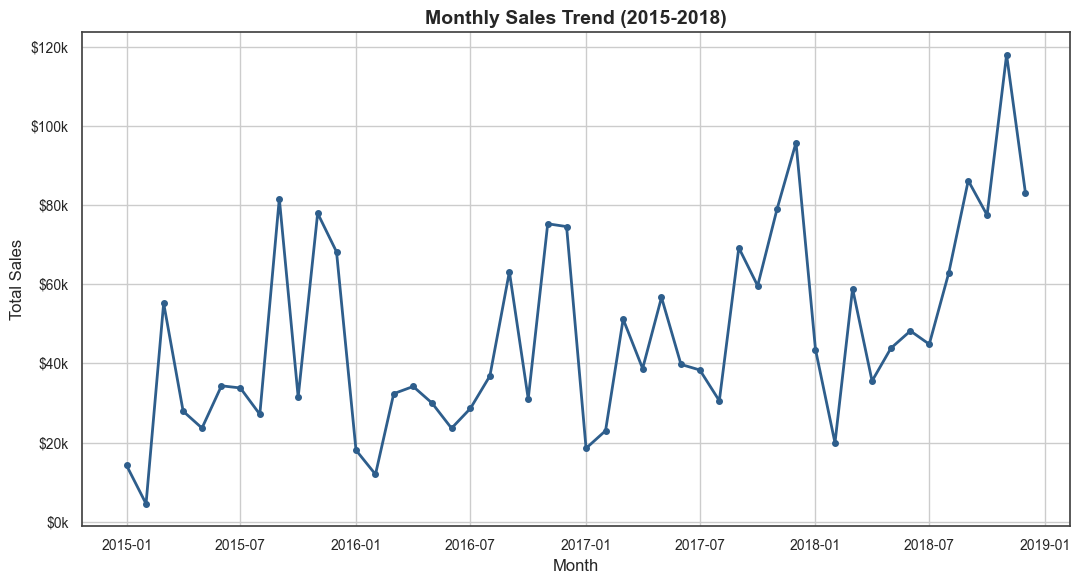

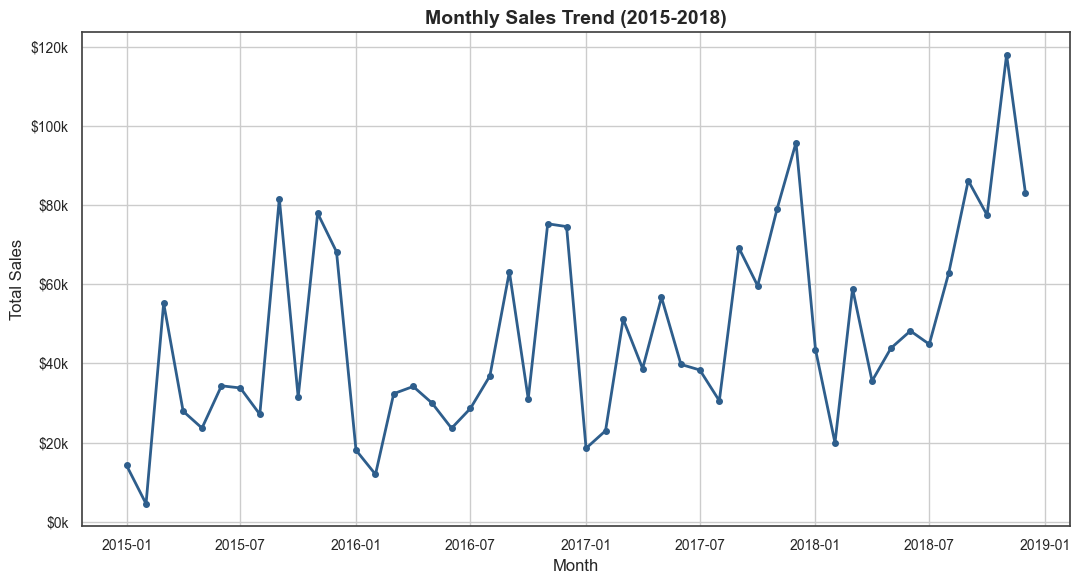

In [20]:
monthly_series = ts.load_monthly_series()
print(f"{len(monthly_series)} monthly observations "
      f"from {monthly_series.index.min():%Y-%m} to {monthly_series.index.max():%Y-%m} "
      f"(frequency: {monthly_series.index.freqstr})")

charts.plot_monthly_sales_trend(monthly)  # reuse the Phase 2 monthly frame for the trend view

### 2.2 Seasonal decomposition

The decomposition uses a classical additive model with a 12-month period. Additive was chosen
over multiplicative because the seasonal swing stays roughly constant in absolute dollar
terms — its year-on-year coefficient of variation actually falls as sales grow, from 0.6 in
2015 to 0.4 in 2018 — whereas a multiplicative model assumes the seasonal amplitude scales
with the level, which isn't what the data shows here. The period is set to 12 because monthly
retail data has an annual cycle. Classical decomposition is a reasonable fit for a clean
48-month series; something like STL would add complexity without much benefit when a fixed
annual pattern and a readable result are all that's needed.

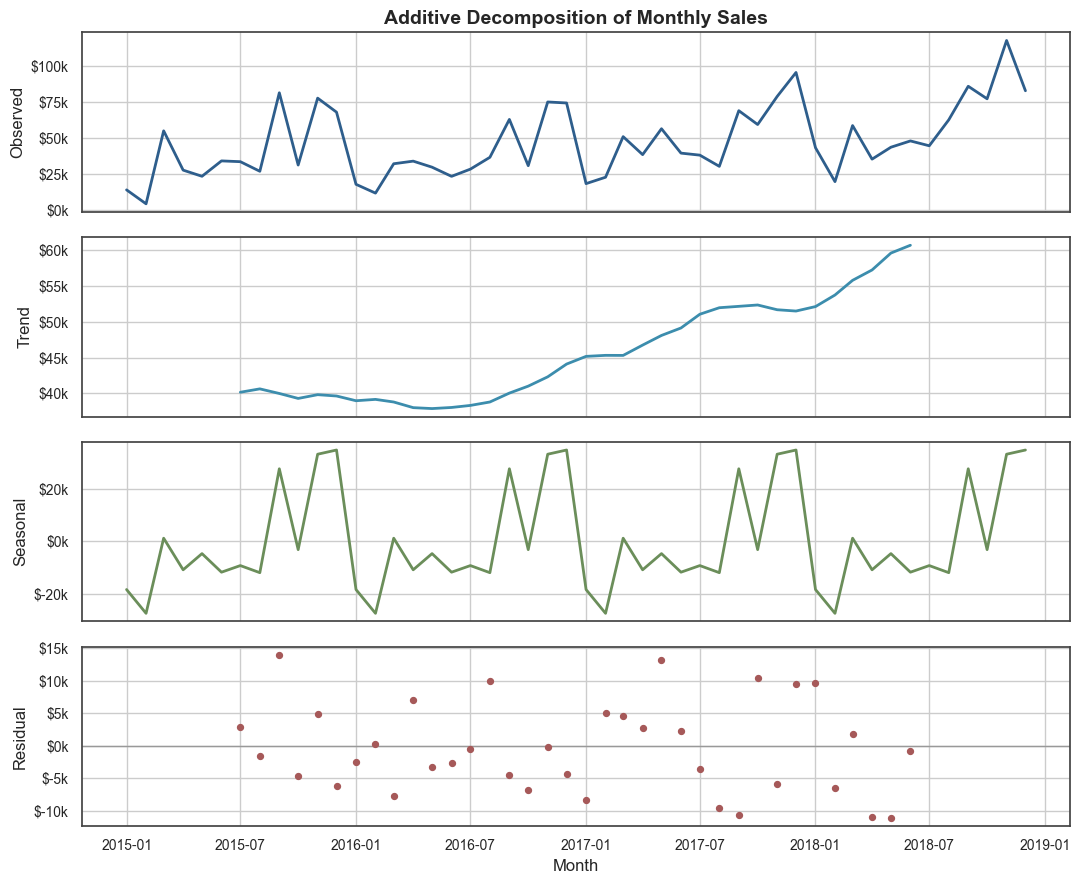

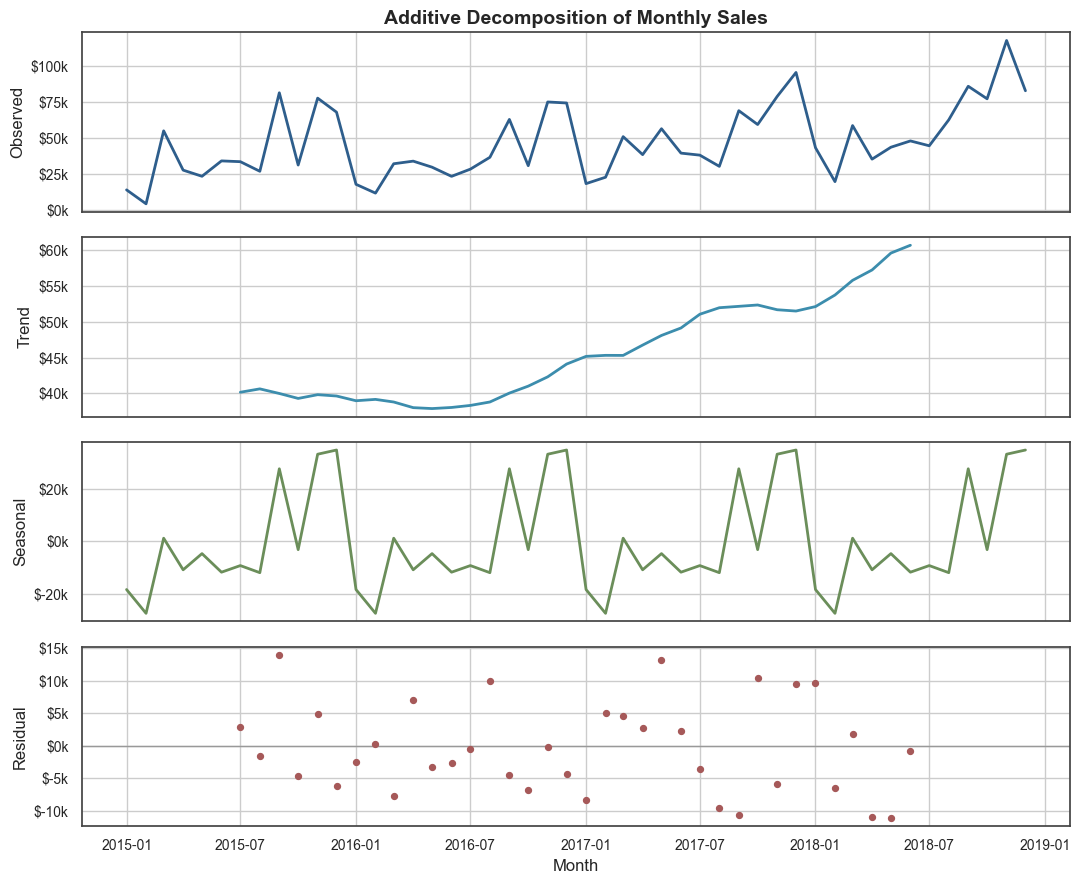

In [21]:
decomposition = ts.decompose_monthly_sales(monthly_series, model="additive", period=12)
decomposition_fig = charts.plot_seasonal_decomposition(decomposition)
save_figure(decomposition_fig, "seasonal_decomposition.png")
decomposition_fig

Saying "seasonality looks strong" from a chart alone isn't much of a claim, so each component
gets measured with the Hyndman-Athanasopoulos strength statistic —
`1 - Var(residual) / Var(component + residual)`, where 0 means the component adds nothing and
1 means it dominates — alongside the seasonal effect of each individual month.

In [22]:
strength = ts.component_strength(decomposition)
strength

trend_strength      0.40
seasonal_strength   0.89
dtype: float64

In [23]:
ts.seasonal_factors(decomposition).sort_values()

Feb   -27,368.00
Jan   -18,307.00
Aug   -11,883.00
Jun   -11,699.00
Apr   -10,788.00
Jul    -9,185.00
May    -4,627.00
Oct    -3,115.00
Mar     1,245.00
Sep    27,676.00
Nov    33,224.00
Dec    34,827.00
Name: Seasonal Factor, dtype: float64

In [24]:
decomposition.resid.describe().round(0)

count        36.00
mean       -415.00
std       7,041.00
min     -11,158.00
25%      -5,952.00
50%      -1,215.00
75%       4,686.00
max      13,971.00
Name: resid, dtype: float64

### 2.3 Observations from the decomposition

The trend turns out to be mild and back-loaded rather than steady — its strength is only
0.40. It's essentially flat, even falling slightly, through 2015 and 2016, bottoming near
$37.9k in May 2016, before climbing to roughly $60.7k by late 2018. That's a 51% rise, but
almost all of it happened in the final two years, so calling this a "growing business" needs
the caveat that the growth is recent, not a constant feature of the whole period.

Seasonality, by contrast, is the dominant signal in this series — its strength comes out to
0.89, far above the trend. The seasonal swing runs from +$34.8k in December and +$33.2k in
November down to -$27.4k in February, a peak-to-trough range of about $62k. That's larger
than the entire four-year trend movement of roughly $23k, which means any forecasting model
that treats this as a simple upward trend and ignores the annual cycle is going to be badly
wrong. The months driving that swing line up with what Task 1 already found: September,
November, and December are the only months with a positive seasonal effect, and January and
February are the deepest troughs — a back-to-work September followed by the November-December
holiday surge and then a post-holiday lull.

What's left over after removing trend and seasonality is fairly unremarkable, which is a good
sign. The residual standard deviation is about $7.0k, roughly 15% of average monthly sales,
with the largest positive shock in September 2015 (+$14.0k) and the largest negative one in
May 2018 (-$11.2k). They scatter around zero with no visible pattern, meaning trend and
seasonality together are capturing most of what's systematic in the data, and what remains is
genuine month-to-month noise rather than a missed structural signal.

### 2.4 Stationarity and the Augmented Dickey-Fuller test

In plain terms, a series is stationary if its statistical behaviour doesn't depend on when
you happen to look at it — the average level, the variability, and the month-to-month
relationships all stay roughly the same over time. A non-stationary series drifts instead: its
mean wanders, which makes the past a weaker guide to the future.

This matters here because the SARIMA model used in Task 3 assumes the part of the series it
models is stationary. Feeding it a drifting series would make its error estimates and
forecasts unreliable, so it's worth checking now rather than finding out the hard way later.
The Augmented Dickey-Fuller test checks for what's called a unit root, the statistical
fingerprint of a wandering, non-stationary trend — its null hypothesis is that the series has
one. It's run two ways below: once around a constant mean, and once allowing for a
deterministic trend.

In [25]:
adf_levels = ts.adf_test(monthly_series, regression="c")
adf_levels

adf_statistic    -4.42
p_value           0.00
used_lag             0
n_observations      47
is_stationary     True
critical_1%      -3.58
critical_5%      -2.92
critical_10%     -2.60
dtype: object

In [26]:
adf_levels_with_trend = ts.adf_test(monthly_series, regression="ct")
adf_levels_with_trend

adf_statistic    -3.64
p_value           0.03
used_lag             8
n_observations      39
is_stationary     True
critical_1%      -4.21
critical_5%      -3.53
critical_10%     -3.20
dtype: object

The p-value tells you how likely this data would be if the series really were non-stationary.
Here it comes out to 0.0003 with a constant mean and 0.027 allowing for a trend — both well
below the usual 0.05 cutoff, so the non-stationary null gets rejected under both
specifications. The test statistic itself, -4.42, is more negative than the 5% critical value
of -2.93 and even the 1% value of -3.58, which is further confirmation: the more negative the
statistic relative to those thresholds, the stronger the evidence against a unit root.

So the monthly series is already stationary. That might seem surprising given the visible
upward drift, but the drift is mild next to the strong, mean-reverting annual cycle — sales
reliably fall back every winter — so there's no wandering stochastic trend for the test to
pick up on.

### 2.5 Differencing: necessary, or over-differencing?

Since the level series is already stationary, first-order differencing isn't actually required
to satisfy SARIMA's assumptions. It's applied once anyway below, not because it's needed, but
to check whether it would help or quietly make things worse.

adf_statistic    -8.73
p_value           0.00
used_lag            10
n_observations      36
is_stationary     True
critical_1%      -3.63
critical_5%      -2.95
critical_10%     -2.61
dtype: object

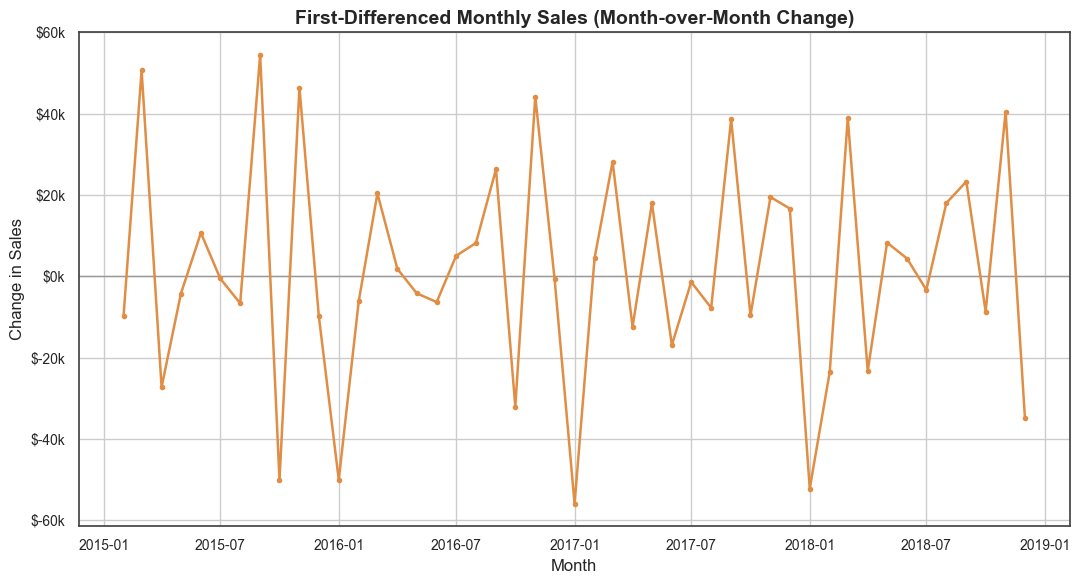

In [27]:
monthly_diff = ts.difference_series(monthly_series, order=1)
adf_differenced = ts.adf_test(monthly_diff)
save_figure(charts.plot_first_difference(monthly_diff), "first_difference.png")
adf_differenced

In [28]:
ts.over_differencing_diagnostics(monthly_series, monthly_diff)

variance_level              623,934,819.46
variance_differenced        745,512,893.70
variance_ratio                        1.20
lag1_autocorr_level                   0.37
lag1_autocorr_differenced            -0.41
dtype: float64

Differencing does push the ADF p-value down toward zero, but that isn't evidence it helped —
the series already passed the test before this step. Two other diagnostics point the other
way: the differenced variance comes out about 19% larger than the level variance, when
differencing that actually helps should reduce variance, and the lag-1 autocorrelation flips
from a mild +0.37 to -0.41. A sharp negative lag-1 autocorrelation like that is the textbook
signature of over-differencing.

So the series stays at its original level for modelling, with no differencing applied. A
second difference would only compound the problem. The annual seasonality gets handled
instead through the seasonal terms of the SARIMA model built in Task 3.

## Task 3 — Sales Forecasting using Three Different Models

This is the core forecasting task: build three genuinely different models for monthly sales,
compare them honestly, and settle on one for production. The three models make very different
assumptions about the data. SARIMA is a statistical state-space model — it assumes sales
depend linearly on their own recent past plus a fixed annual cycle. Prophet is an additive
Bayesian decomposition — trend plus Fourier seasonality plus noise. XGBoost is a gradient-
boosted tree ensemble, treating sales as a non-linear function of engineered lag and calendar
features.

Time-series data can never be shuffled for evaluation — that would let a model see the future
during training. So the evaluation here follows a strict protocol: split the series
chronologically, holding out the most recent three months (2018 Q4); fit each model on the
training months only and score it against the held-out actuals with MAE, RMSE, and MAPE; and
because a three-point hold-out is noisy on its own, add a rolling-origin backtest — repeated
refits on expanding windows — to check whether the ranking actually holds up. All of the model
code lives in dedicated `src/models/` modules; this notebook just orchestrates it and
interprets the results.

### 3.1 Chronological train / test split

The last three months are held out and never seen during training. Every model below is fit
only on `train`, so there's no leakage from the evaluation period.

In [29]:
train, test = ev.chronological_split(monthly_series, horizon=3)
print(f"Train: {len(train)} months  ({train.index.min():%Y-%m} → {train.index.max():%Y-%m})")
print(f"Test : {len(test)} months  ({test.index.min():%Y-%m} → {test.index.max():%Y-%m})  [held out]")

Train: 45 months  (2015-01 → 2018-09)
Test : 3 months  (2018-10 → 2018-12)  [held out]


### 3.2 Model 1 — SARIMA

SARIMA's orders are picked from evidence rather than left at some default. `d = 0` because
Task 2 already showed the non-seasonal series is stationary (ADF p = 0.0003) and that
differencing it over-corrects. The ACF and PACF below show only weak short-lag structure —
lag-1 sits around 0.2 and drops close to zero after that — which points to small non-seasonal
orders of 1 or less. The seasonal period is set to 12, matching the annual cycle in monthly
data, and `D = 1` because a single strong spike at lag 12 in both the ACF and PACF signals
seasonal non-stationarity in the yearly pattern specifically — distinct from the non-seasonal
stationarity already established in Task 2.

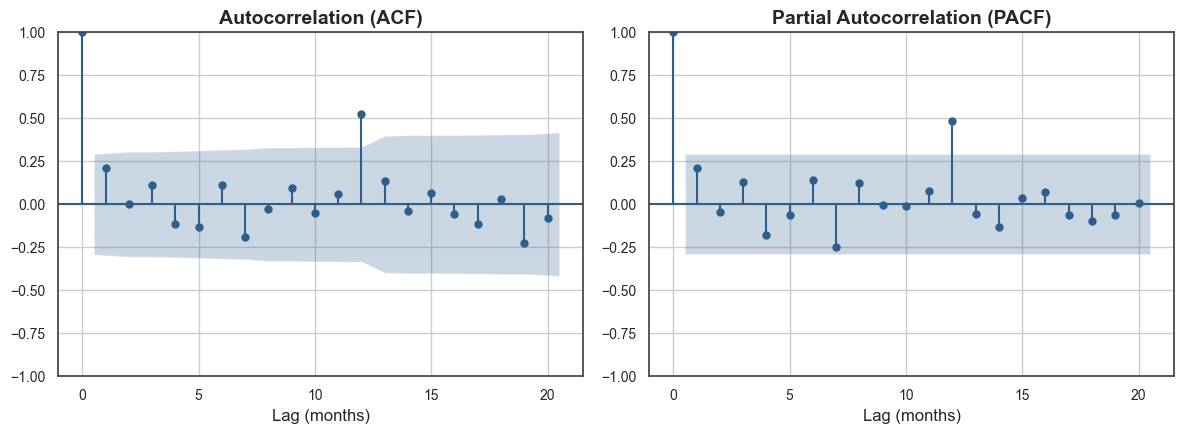

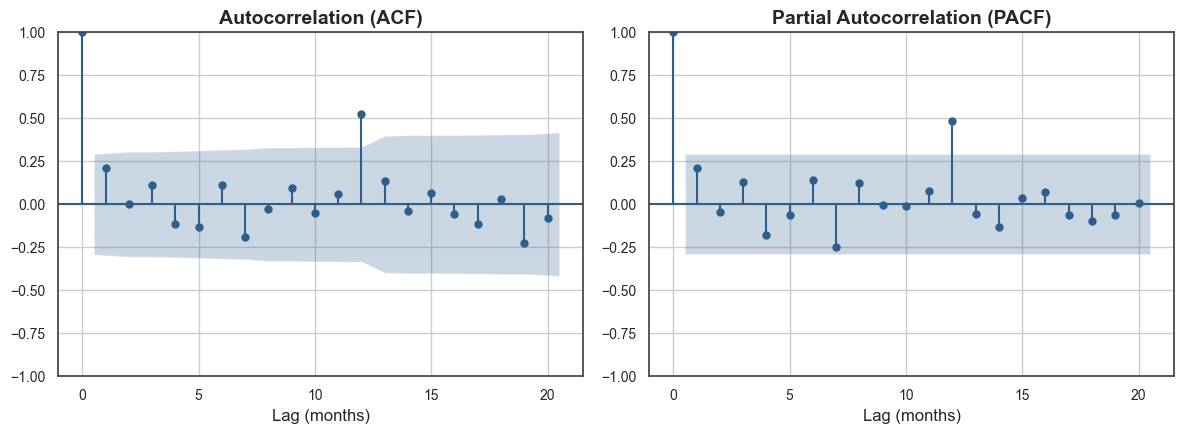

In [30]:
acf_pacf_fig = charts.plot_acf_pacf(train, lags=20)
save_figure(acf_pacf_fig, "acf_pacf.png")
acf_pacf_fig

The plots back up that reasoning: no meaningful non-seasonal spikes, one dominant spike at
lag 12. That justifies searching a compact grid where every order sits in {0, 1} with `d = 0`
fixed, ranked by AICc — the small-sample-corrected version of AIC, appropriate here given only
45 training points. It's a targeted search grounded in what the ACF/PACF actually show, not a
brute-force sweep over arbitrary orders.

In [31]:
order_search = sarima.sarima_order_search(train)
order_search.head(6)

,order,seasonal_order,AIC,AICc,BIC
0,"(1, 0, 1)","(0, 1, 1, 12)",416.40,417.40,420.20
1,"(1, 0, 1)","(1, 1, 1, 12)",417.40,418.90,422.10
2,"(0, 0, 1)","(0, 1, 1, 12)",422.80,423.40,425.70
3,"(0, 0, 1)","(1, 1, 1, 12)",424.80,425.80,428.60
4,"(1, 0, 1)","(1, 1, 0, 12)",437.30,438.30,441.30
5,"(1, 0, 0)","(0, 1, 1, 12)",443.10,443.70,446.10


AICc picks out SARIMA(1,0,1)(0,1,1)₁₂ — the classic "airline model" structure. After fitting
it, the Ljung-Box test checks whether the residuals are indistinguishable from white noise,
which is what confirms the model actually captured the series' structure rather than leaving
something behind.

In [32]:
sarima_fit = sarima.fit_sarima(train)
print(f"Selected: SARIMA{sarima.SELECTED_ORDER} x {sarima.SELECTED_SEASONAL_ORDER}")
print(f"Ljung-Box(12) residual p-value: {sarima.ljung_box_pvalue(sarima_fit):.3f} "
      f"(> 0.05 ⇒ residuals ~ white noise, model adequate)")

sarima_holdout = sarima.sarima_forecast(sarima_fit, horizon=3)
sarima_metrics = ev.forecast_metrics(test, sarima_holdout["forecast"])
sarima_metrics.round(1)

Selected: SARIMA(1, 0, 1) x (0, 1, 1, 12)
Ljung-Box(12) residual p-value: 0.445 (> 0.05 ⇒ residuals ~ white noise, model adequate)


MAE    20,043.10
RMSE   21,438.30
MAPE       21.00
dtype: float64

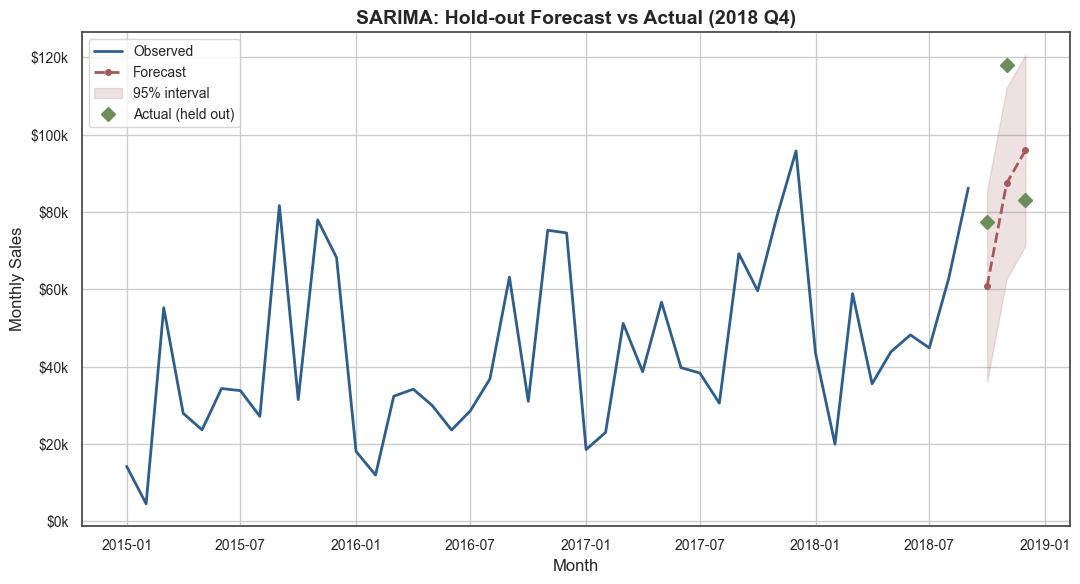

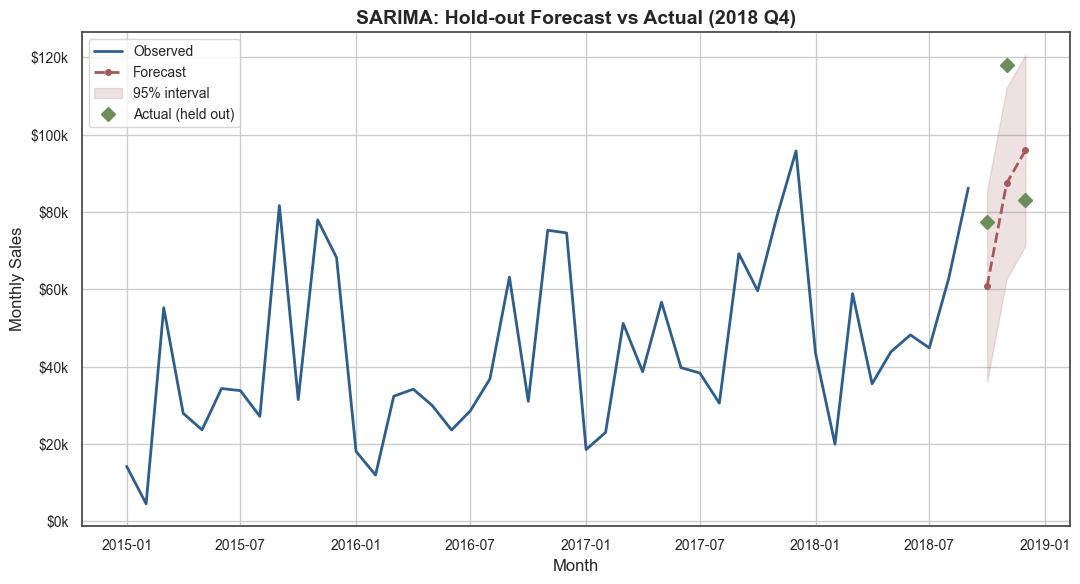

In [33]:
sarima_holdout_fig = charts.plot_forecast(
    train, sarima_holdout, actual=test,
    title="SARIMA: Hold-out Forecast vs Actual (2018 Q4)",
)
save_figure(sarima_holdout_fig, "sarima_holdout_forecast.png")
sarima_holdout_fig

The forecast tracks the Q4 seasonal rise well, and its 95% interval contains both October and
December. It does underestimate the November 2018 spike of $117.9k, which sits just above the
interval — consistent with what Task 2 already flagged, since that month held the single
largest residual in the whole series and looks like an anomaly rather than typical seasonal
behaviour (revisited properly in Task 5). For the production forecast, the model is refit on
all 48 months and projected forward into 2019 Q1 with confidence intervals.

            forecast     lower     upper
2019-01-01 50,101.00 23,170.00 77,031.00
2019-02-01 35,740.00  8,812.00 62,669.00
2019-03-01 69,683.00 42,760.00 96,606.00


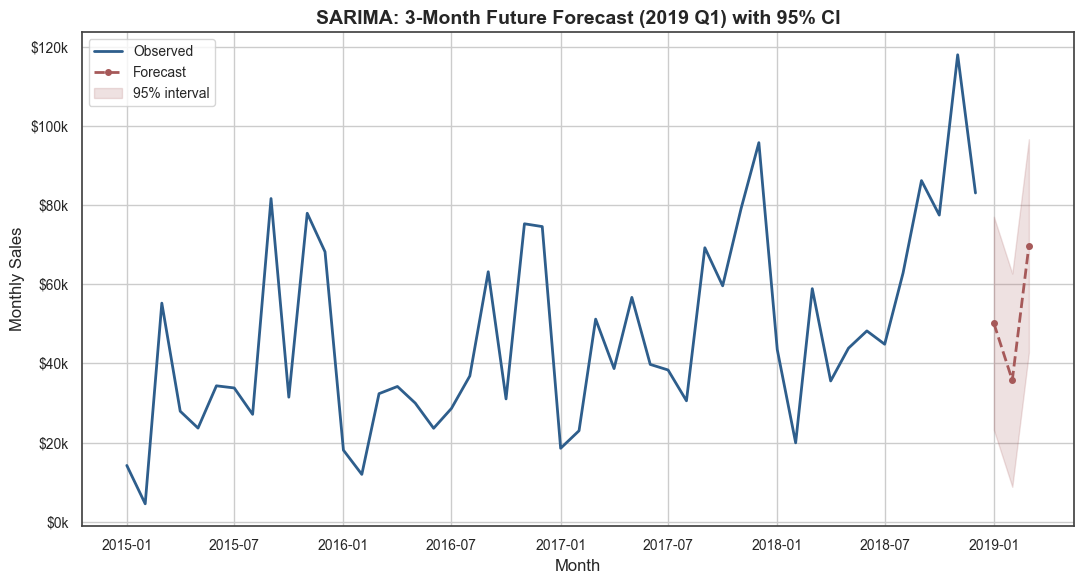

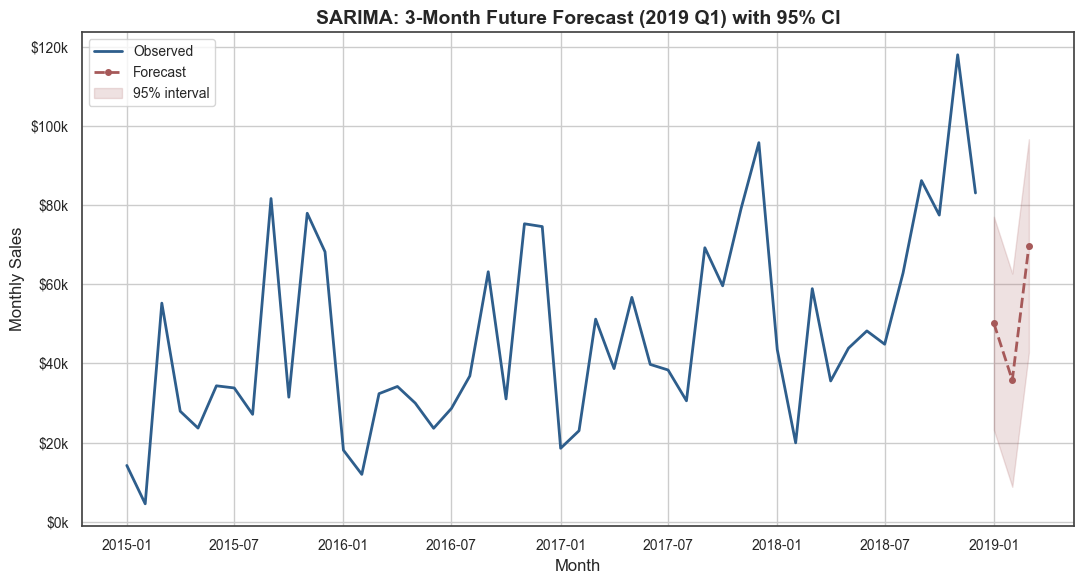

In [34]:
sarima_full = sarima.fit_sarima(monthly_series)
sarima_future = sarima.sarima_forecast(sarima_full, horizon=3)
print(sarima_future.round(0).to_string())

sarima_future_fig = charts.plot_forecast(
    monthly_series, sarima_future,
    title="SARIMA: 3-Month Future Forecast (2019 Q1) with 95% CI",
)
save_figure(sarima_future_fig, "sarima_future_forecast.png")
sarima_future_fig

### 3.3 Model 2 — Facebook Prophet

Prophet's defaults are tuned for daily data with multiple overlapping seasonalities, so
several settings get adjusted here for a 48-point monthly series. Weekly and daily
seasonality are switched off entirely — monthly totals can't resolve patterns at that
resolution, and leaving them on would just fit noise (it's also why Prophet's component plot
below has no weekly panel; a weekly effect simply isn't a meaningful concept for monthly
data). Yearly seasonality is capped at a Fourier order of 4 instead of the default 10, since
with only 12 points per annual cycle, 10 harmonics would overfit the shape rather than capture
it — order 4 is enough to represent a smooth peak and trough. The model runs in additive mode,
matching the Task 2 finding that the seasonal swing stays roughly constant in dollar terms, and
`changepoint_prior_scale` is lowered to 0.05 to keep the trend smooth rather than letting it
bend to noise on such a small training set. The confidence interval is set to 95%, matching
SARIMA's, so the two are directly comparable.

In [35]:
prophet_train = prophet_fc.fit_prophet(train)
prophet_train_forecast = prophet_fc.prophet_forecast(prophet_train, horizon=3)
prophet_holdout = prophet_train_forecast["yhat"].to_numpy()[-3:]
prophet_metrics = ev.forecast_metrics(test, prophet_holdout)
prophet_metrics.round(1)

MAE    20,788.00
RMSE   22,777.50
MAPE       21.50
dtype: float64

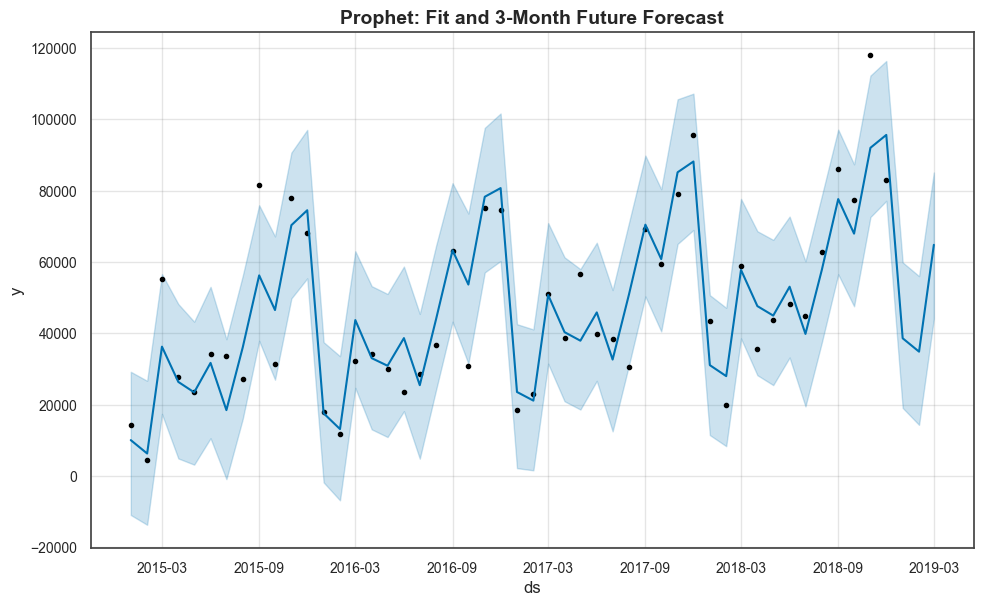

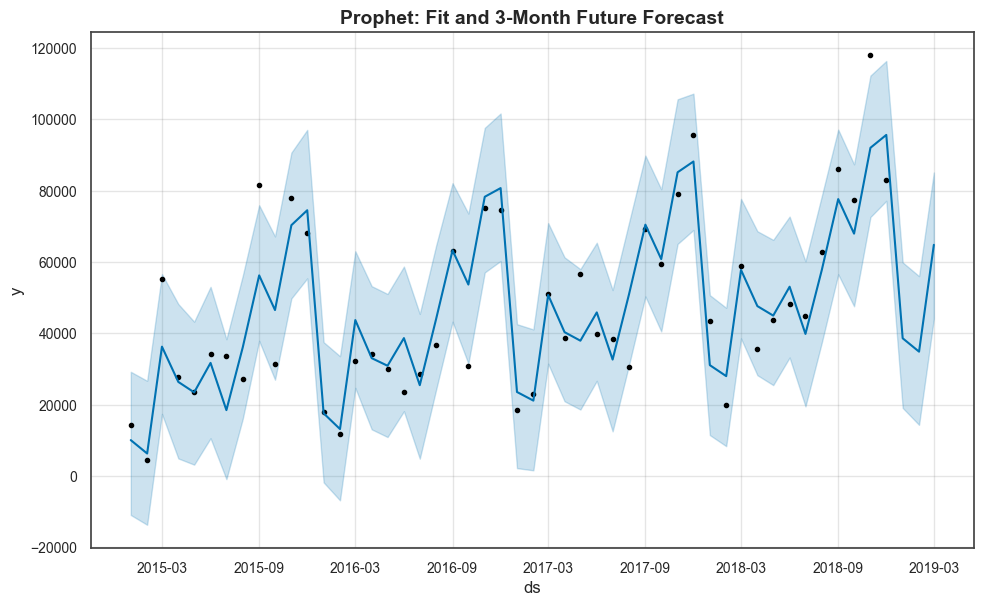

In [36]:
prophet_full = prophet_fc.fit_prophet(monthly_series)
prophet_future = prophet_fc.prophet_forecast(prophet_full, horizon=3)

prophet_forecast_fig = prophet_full.plot(prophet_future)
prophet_forecast_fig.axes[0].set_title("Prophet: Fit and 3-Month Future Forecast")
save_figure(prophet_forecast_fig, "prophet_forecast.png")
prophet_forecast_fig

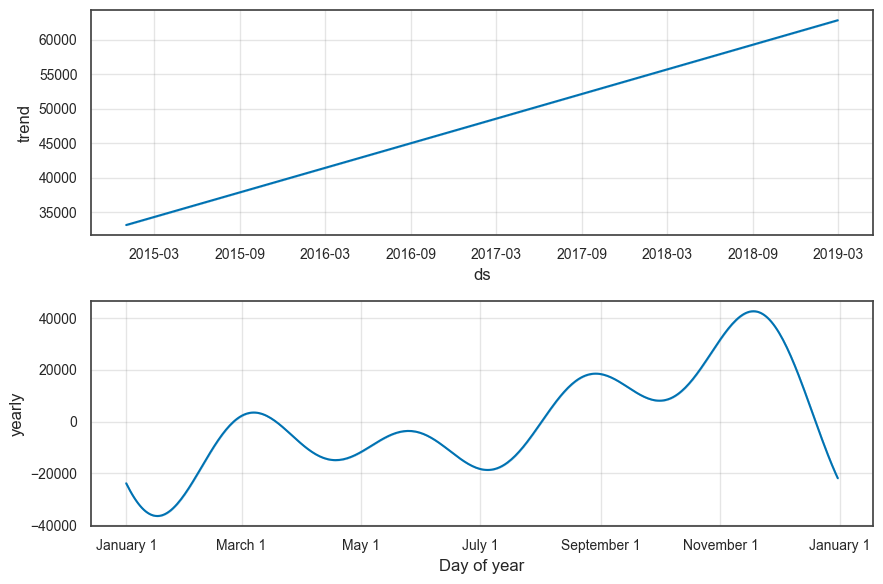

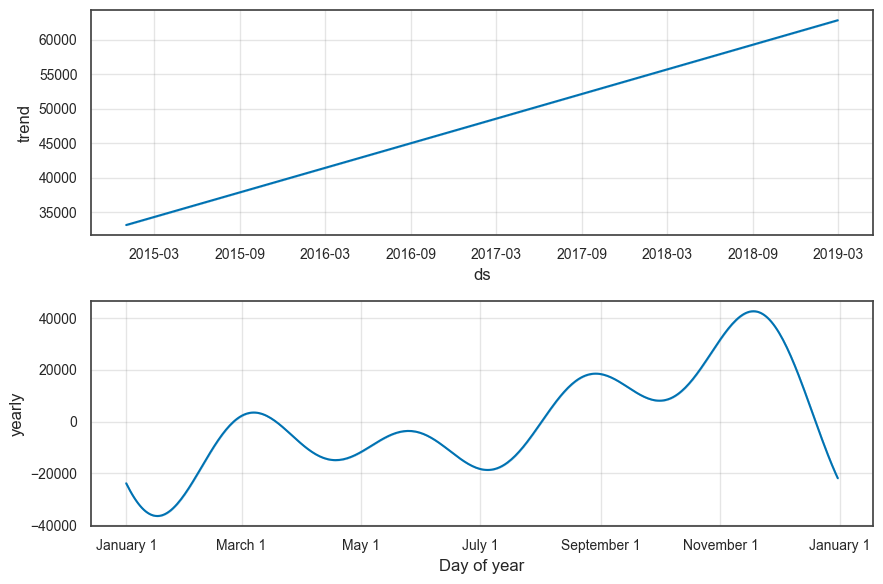

In [37]:
prophet_components_fig = prophet_full.plot_components(prophet_future)
save_figure(prophet_components_fig, "prophet_components.png")
prophet_components_fig

Prophet's components back up Task 2's findings using a completely independent method: an
almost-linear trend rising from about $33k in 2015 to roughly $63k by 2019, and a yearly
seasonality that peaks in November and troughs in February, with a secondary bump in
September — the same back-to-school and holiday pattern seen throughout this analysis. There's
no weekly component, exactly as configured, since the data is monthly. Prophet's hold-out
accuracy comes in close to SARIMA's.

### 3.4 Model 3 — XGBoost (time series as supervised learning)

A tree ensemble can't take a raw series as input, so each month gets turned into a feature row
built only from its own past: lags 1 through 3, a 3-month rolling mean, and calendar position
(month, quarter, season). The lags and rolling mean capture short-term momentum and a smoothed
recent level, while month, quarter, and season let the trees learn the annual pattern directly
— season is really just a coarser version of month, but it's included per the brief and still
gives the trees a low-cardinality seasonal split to work with on limited data. One feature is
deliberately left out: a raw time index. Trees extrapolate a monotonic index by clamping it
flat at the last value they saw during training, which would quietly bias any future forecast.

The hyperparameters are set for a small-sample regime rather than brute-force tuned — with
only 42 training rows, any validation-based tuning would just overfit to noise. That means a
shallow `max_depth` of 3, a low `learning_rate` of 0.05 paired with 200 estimators, and
regularisation through `subsample`, `colsample_bytree`, and `reg_lambda`. The reasoning behind
each is documented in `xgboost_forecaster.XGB_PARAMS`.

One structural limitation is worth flagging up front: trees cannot extrapolate beyond the
range of values they saw during training, so on a trending series like this one, XGBoost will
tend to under-forecast new highs. That gets verified directly below.

In [38]:
X_train, y_train = xgb_fc.make_supervised(train)
print(f"Supervised training rows: {len(X_train)} "
      f"(first {max(xgb_fc.LAGS)} months dropped — no lag history yet)")
X_train.head()

Supervised training rows: 42 (first 3 months dropped — no lag history yet)


,lag_1,lag_2,lag_3,rolling_mean_3,month,quarter,season
2015-04-01,"55,205.80","4,519.89","14,205.71","24,643.80",4,2,1
2015-05-01,"27,906.85","55,205.80","4,519.89","29,210.85",5,2,1
2015-06-01,"23,644.30","27,906.85","55,205.80","35,585.65",6,2,2
2015-07-01,"34,322.94","23,644.30","27,906.85","28,624.70",7,3,2
2015-08-01,"33,781.54","34,322.94","23,644.30","30,582.93",8,3,2


In [39]:
xgb_model = xgb_fc.fit_xgboost(X_train, y_train)
xgb_holdout = xgb_fc.recursive_forecast(xgb_model, train, horizon=3)
xgb_metrics = ev.forecast_metrics(test, xgb_holdout)
print(xgb_metrics.round(1).to_string())
print(f"\nTraining target range: [{y_train.min():,.0f}, {y_train.max():,.0f}] "
      f"— tree forecasts are structurally bounded within this range")
xgb_fc.feature_importance(xgb_model).round(3)

MAE    16,113.50
RMSE   19,527.30
MAPE       15.80

Training target range: [11,951, 95,739] — tree forecasts are structurally bounded within this range


quarter          0.43
month            0.30
season           0.11
rolling_mean_3   0.04
lag_2            0.04
lag_1            0.04
lag_3            0.03
dtype: float32

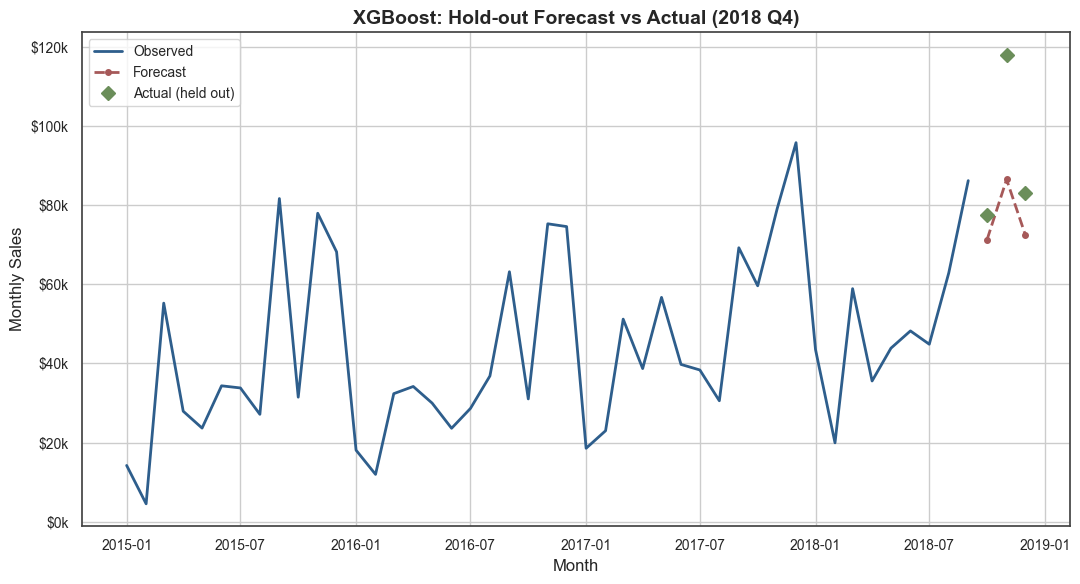

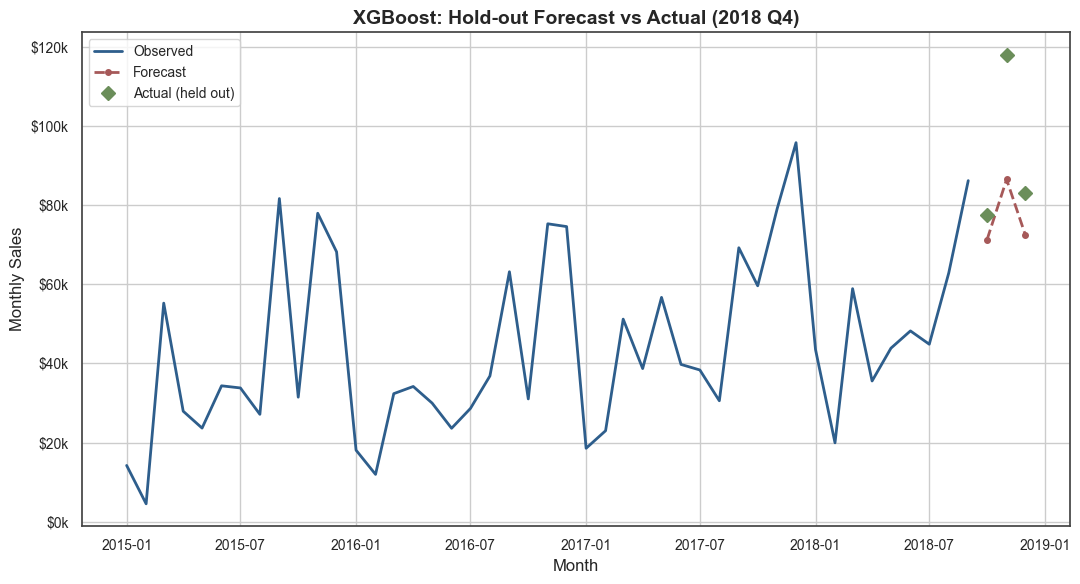

In [40]:
xgb_holdout_fig = charts.plot_forecast(
    train, xgb_holdout.to_frame("forecast"), actual=test,
    title="XGBoost: Hold-out Forecast vs Actual (2018 Q4)",
)
save_figure(xgb_holdout_fig, "xgboost_holdout_forecast.png")
xgb_holdout_fig

The feature importances turn out to be dominated by quarter and month, with the lag features
contributing comparatively little — XGBoost is essentially learning the seasonal calendar
rather than a trend. That explains both why its hold-out fit looks respectable, since Q4 is a
well-defined calendar pattern the model has seen before, and its core weakness: leaning on
calendar features and being capped at the training range gives it no real mechanism to project
the upward trend into genuinely new territory.

### 3.5 Model comparison and recommendation

The comparison starts with the required table from the single hold-out — metrics plus each
model's three monthly forecasts — and then stress-tests that ranking with the rolling-origin
backtest.

In [41]:
comparison = pd.DataFrame(
    {"SARIMA": sarima_metrics, "Prophet": prophet_metrics, "XGBoost": xgb_metrics}
).T
holdout_forecasts = pd.DataFrame(
    {
        "SARIMA": sarima_holdout["forecast"].to_numpy(),
        "Prophet": prophet_holdout,
        "XGBoost": xgb_holdout.to_numpy(),
    },
    index=[f"Forecast {d:%Y-%m}" for d in test.index],
).T
comparison_table = comparison.join(holdout_forecasts).round(1)
print("Actuals (2018 Q4): " + ", ".join(f"{d:%Y-%m}=${v:,.0f}" for d, v in test.items()))
comparison_table

Actuals (2018 Q4): 2018-10=$77,448, 2018-11=$117,938, 2018-12=$83,030


,MAE,RMSE,MAPE,Forecast 2018-10,Forecast 2018-11,Forecast 2018-12
SARIMA,"20,043.10","21,438.30",21.00,"60,792.40","87,357.80","95,923.80"
Prophet,"20,788.00","22,777.50",21.50,"61,048.70","84,205.50","95,262.20"
XGBoost,"16,113.50","19,527.30",15.80,"71,277.50","86,443.60","72,355.10"


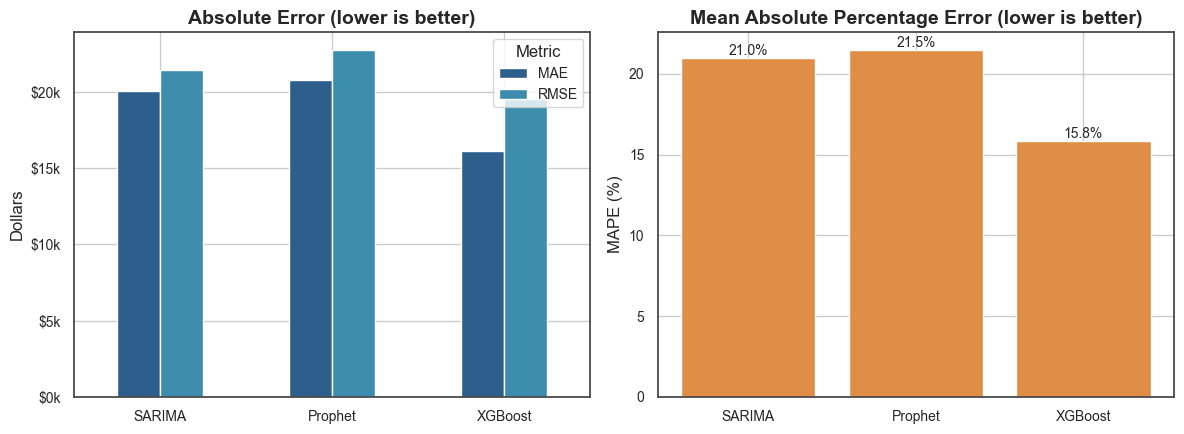

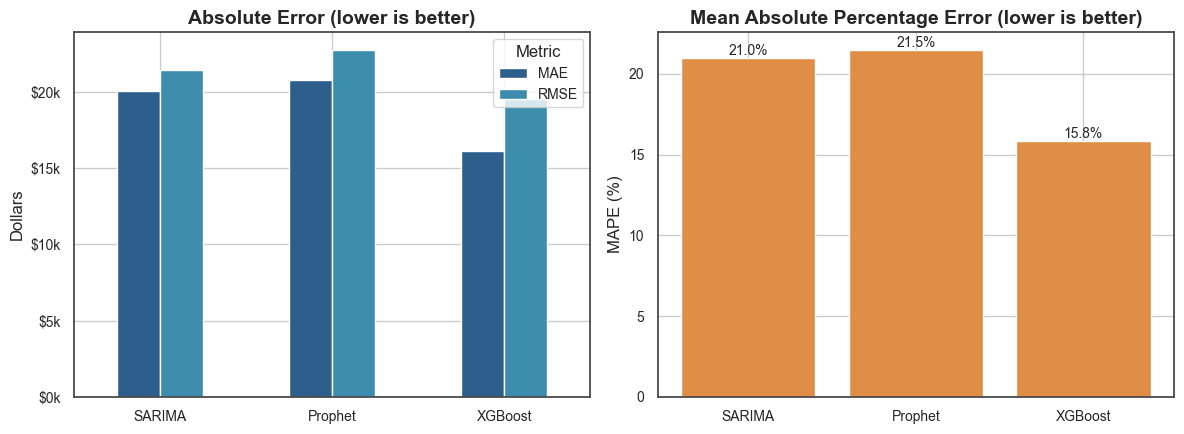

In [42]:
comparison_fig = charts.plot_model_comparison(comparison)
save_figure(comparison_fig, "model_comparison.png")
comparison_fig

On this single window, XGBoost comes out with the lowest error — but a three-point test is
easy for one lucky (or unlucky) window to swing. The rolling-origin backtest refits every
model across six expanding-window origins, pooling 18 forecast points, to check whether that
ranking actually holds.

In [43]:
forecasters = {
    "SARIMA": sarima.point_forecast,
    "Prophet": prophet_fc.point_forecast,
    "XGBoost": xgb_fc.point_forecast,
}
backtest = ev.rolling_origin_backtest(monthly_series, forecasters, horizon=3, n_origins=6)
backtest.round(1)

,forecast_points,MAE,RMSE,MAPE
Prophet,18,"13,512.70","15,913.40",18.00
SARIMA,18,"13,322.50","16,378.30",17.70
XGBoost,18,"14,724.20","17,424.10",20.40


It doesn't. Under the more reliable backtest, SARIMA and Prophet come out effectively tied and
both clearly beat XGBoost, at roughly 18% MAPE versus 20%. XGBoost's single-window lead was
noise from an n of 3 — exactly the kind of fragility you'd expect from a data-hungry model
that can't extrapolate. For completeness, here's the genuine next-quarter forecast from each
model, refit on all 48 months:

In [44]:
future_index = pd.date_range(
    monthly_series.index[-1] + pd.offsets.MonthBegin(1), periods=3, freq="MS"
)
xgb_full = xgb_fc.fit_xgboost(*xgb_fc.make_supervised(monthly_series))
future_forecasts = pd.DataFrame(
    {
        "SARIMA": sarima_future["forecast"].to_numpy(),
        "Prophet": prophet_future["yhat"].to_numpy()[-3:],
        "XGBoost": xgb_fc.recursive_forecast(xgb_full, monthly_series, horizon=3).to_numpy(),
    },
    index=future_index.strftime("%Y-%m"),
).round(0)
future_forecasts

,SARIMA,Prophet,XGBoost
2019-01,"50,101.00","38,648.00","44,927.00"
2019-02,"35,740.00","34,897.00","34,856.00"
2019-03,"69,683.00","64,852.00","54,096.00"


The recommendation is SARIMA for production, with Prophet as an equally strong alternative,
and the decision follows the numbers rather than a preference. The rolling-origin backtest —
the evidence that actually matters here — puts SARIMA and Prophet in a statistical dead heat:
SARIMA has the best MAE at 13.3k, Prophet edges ahead on RMSE and MAPE by about 3%, well
within noise. XGBoost finishes last on every metric in the backtest, which rules it out
despite its lucky single-window result — it needs more history than 48 months to be
competitive, it can't extrapolate the trend, and it offers no native uncertainty interval.

Between the two co-leaders, SARIMA gets the nod for production because, at essentially
equivalent accuracy, it comes with properties a business forecast actually needs: residuals
that pass the white-noise test (Ljung-Box p = 0.45), calibrated confidence intervals from a
transparent statistical model, and a compact, interpretable structure. Prophet remains a fully
acceptable substitute and would be the easier of the two to extend later with holiday effects
or external regressors.

One honest caveat: with four years of history, the hold-out sample is small, so these metrics
are indicative rather than definitive on their own — it's the rolling-origin backtest that
makes the ranking trustworthy. All three models under-predict the exceptional November 2018
peak, which is better understood as an anomaly, covered properly in Task 5, than as something
a smooth forecast should be expected to chase.

## Task 4 — Product Category & Region Level Forecasting

With a production model chosen, the next question is how it performs at a finer grain. This
section applies the same SARIMA(1,0,1)(0,1,1)₁₂ specification separately to five business
segments — three product categories and two regions — and looks at which one shows genuine,
credible growth rather than just the biggest headline number.

The exact SARIMA specification and the fitting and forecasting functions from
`src/models/sarima.py` get reused as-is, rather than re-deriving orders per segment or
duplicating any forecasting logic. The new code in `src/models/segment_forecasting.py` only
orchestrates that existing pipeline across the five segments and adds a growth comparison
suited to the business question being asked.

### 4.1 Why reuse one SARIMA order across all five segments

Running a full ACF/PACF-driven order search separately for each of five ~48-point series would
mostly be tuning to noise, given how little data each segment has on its own. A better check is
whether the same seasonal signature seen in the aggregate series in Task 3 — a modest lag-1
autocorrelation and a materially larger spike at the seasonal lag of 12 — shows up in every
segment too. If it does, reusing one order is justified. If a segment looked structurally
different, it would need its own analysis instead.

In [45]:
# `sales` (line-item data with Category/Region) was built once in Task 1 and is reused here
# rather than reloading from disk.
segment_series = {
    name: segment_monthly_series(sales, column, value, full_index=monthly_series.index)
    for name, (column, value) in seg_fc.SEGMENT_DEFINITIONS.items()
}

acf_evidence = pd.DataFrame(
    {name: ts.acf_snapshot(series, lags=(1, 12)) for name, series in segment_series.items()}
).T
acf_evidence

,ACF lag 1,ACF lag 12
Furniture,0.32,0.64
Technology,0.21,0.33
Office Supplies,0.36,0.41
West,0.34,0.48
East,0.38,0.43


Every segment shows the same pattern as the aggregate series: a modest lag-1 autocorrelation
(0.21–0.38) and a clearly larger seasonal spike at lag 12 (0.33–0.64). This confirms the same
SARIMA structure is a reasonable fit across segments, so we proceed with one shared order.

### 4.2 Fit and forecast each segment

For each segment we fit SARIMA(1,0,1)(0,1,1)₁₂ on its full monthly history and forecast three
months ahead, exactly as in Task 3. We again check the **Ljung-Box** residual test per segment
— model adequacy is not assumed to transfer automatically from the aggregate fit.

In [46]:
segment_results = seg_fc.forecast_all_segments(segment_series, horizon=3)

adequacy = pd.DataFrame(
    {name: {"Ljung-Box p-value": round(result["ljung_box_pvalue"], 3)}
     for name, result in segment_results.items()}
).T
adequacy["Residuals ~ white noise (p > 0.05)"] = adequacy["Ljung-Box p-value"] > 0.05
adequacy

,Ljung-Box p-value,Residuals ~ white noise (p > 0.05)
Furniture,0.48,True
Technology,0.52,True
Office Supplies,0.55,True
West,0.64,True
East,0.98,True


All five p-values comfortably exceed 0.05, so the shared specification is statistically
adequate for every segment — none needed a different order.

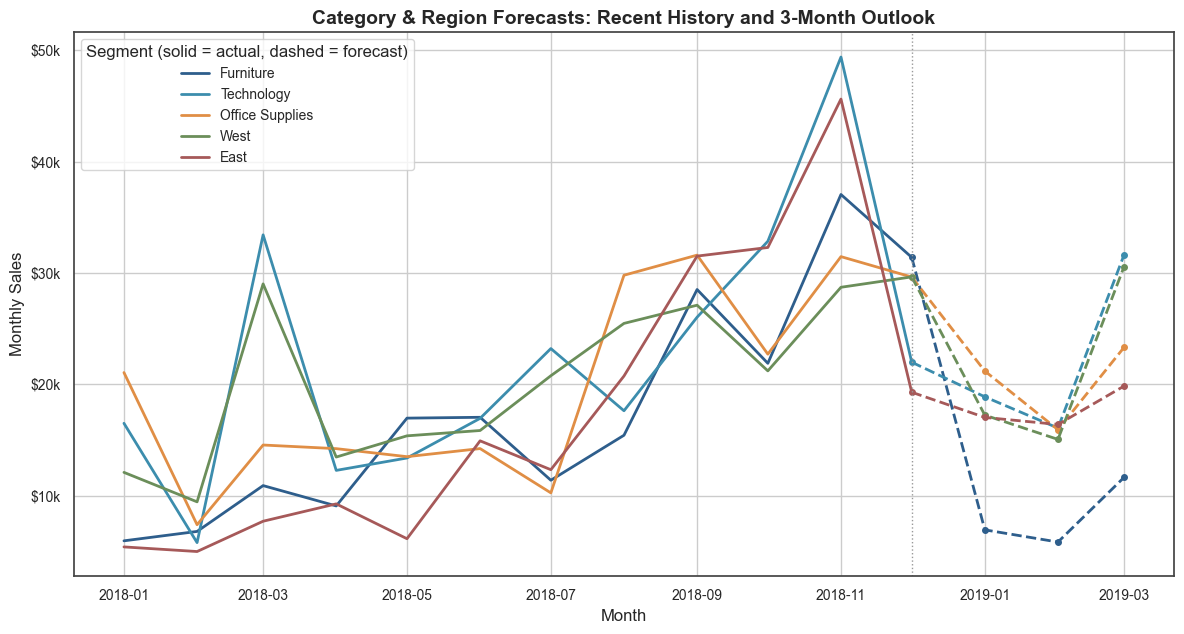

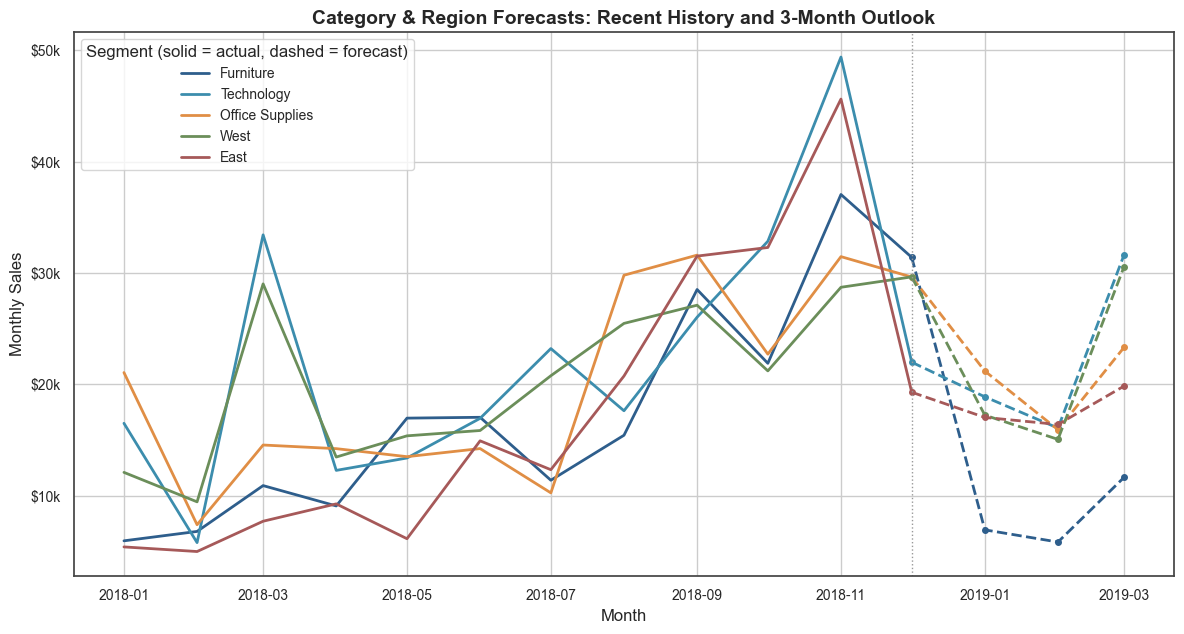

In [47]:
segment_forecast_fig = charts.plot_segment_forecast_comparison(
    segment_series, {name: result["forecast"] for name, result in segment_results.items()}
)
save_figure(segment_forecast_fig, "segment_forecast_comparison.png")
segment_forecast_fig

### 4.3 Growth comparison

The forecast window here is 2019 Q1 — January through March — which Task 2 identified as the
seasonal trough. Comparing that directly to the preceding Q4, the holiday peak, would read as
a decline for every single segment purely because of the calendar, not because of any real
change in demand. So instead, each segment's Q1 2019 forecast is compared to its own Q1 2018
actuals — the same calendar months one year earlier — which isolates genuine year-over-year
growth from the seasonal cycle.

The 95% confidence interval width is reported alongside the growth percentage for a reason: a
large point-forecast gain sitting on a wide interval is a much weaker claim than the same gain
with a tight interval, and as the table below shows, that distinction turns out to matter a
lot here.

In [48]:
growth_summary = seg_fc.summarise_segment_growth(segment_series, segment_results)
growth_summary

,Same Quarter Last Year,Forecast (Next Quarter),YoY Growth %,CI Width % of Forecast,Ljung-Box p-value
Segment,,,,,
East,"18,043.00","53,248.00",195.10,200.00,0.98
Office Supplies,"42,972.00","60,417.00",40.60,146.00,0.55
West,"50,541.00","62,828.00",24.30,125.00,0.64
Technology,"55,690.00","66,551.00",19.50,187.00,0.52
Furniture,"23,598.00","24,365.00",3.30,253.00,0.48


### 4.4 Interpretation

The headline ranking by point-forecast growth alone has East out in front by a wide margin,
at +195%, but that number doesn't hold up to scrutiny on its own. East's Q1 2018 base was
unusually low — $18.0k, its weakest Q1 in the last two years — following a strong second half
of 2018, so a large part of that huge percentage is a low-base effect rather than genuine
forecast growth. Its 95% interval also spans about 200% of its own point forecast, visible in
the chart as the widest and flattest of the five dashed segments, making it one of the least
confident forecasts in the group. The +195% headline is real in the model, but it deserves real
caution rather than being reported at face value.

West looks like the more credible "fastest growing" segment. It shows solid, genuine growth of
+24.3% year over year, and it does so with the tightest confidence interval of all five
segments — about 125% of its point forecast, against 146% to 253% for the rest — which makes
it the forecast a business could actually act on with confidence. Office Supplies is the
runner-up on both counts, with +40.6% growth and a moderately tight 146% interval. Furniture
sits at the other end: materially slower growth at +3.3%, and at the same time the widest
relative interval of any segment at 253%, making it both the weakest growth signal and the
least certain one.

Put into business terms, West offers the best combination of growth and reliability, making
it a reasonable candidate for extra stocking investment ahead of Q1 2019. East's forecast is
better treated as a wide-uncertainty upside scenario worth watching as the quarter unfolds
rather than something to commit inventory against directly. And Furniture's flat, low-
confidence outlook argues for holding stocking levels steady rather than expanding, at least
until a clearer trend emerges.

## Task 5 — Anomaly Detection in Sales Data

This section looks for weeks where sales were unusually high or low relative to what the
pattern would predict, using two methods that make different assumptions: a transparent,
univariate Z-score rule, and a multivariate, model-based Isolation Forest. Comparing where they
agree and where they diverge says something useful about how much to trust each one.

The task calls for weekly sales, so the weekly aggregation built in Task 1 is reused here
rather than re-derived, after first checking it's actually fit for purpose.

One thing worth addressing directly: the internship brief also lists a supplementary Video
Game Sales dataset, described as material "to practice merging and multi-source analysis." It
isn't used here. Task 5's actual requirements — Isolation Forest and Z-score detection on
Superstore weekly sales — are fully self-contained within the Superstore data, and the two
datasets share no natural join key: no common product, order, or geography identifier that
would make a merge anything other than a forced concatenation. Given the standing instruction
to use supplementary data only where it genuinely contributes, it's left out here by design,
not by oversight.

### 5.1 Weekly series data quality

Before detecting anomalies we verify the series is a *reliable* input: correct frequency,
no missing weeks, and aggregation that did not silently drop data.

In [49]:
weekly = ts.load_weekly_sales_frame()
weekly_sales = weekly["Sales"]
order_lines = weekly["Order Lines"]

print(f"{len(weekly)} weekly observations, "
      f"{weekly.index.min():%Y-%m-%d} → {weekly.index.max():%Y-%m-%d} "
      f"(frequency: {weekly.index.freqstr})")
print(f"Missing weeks after reindexing to strict weekly frequency: {weekly.isna().any(axis=1).sum()}")
print(f"Zero-sales weeks: {(weekly_sales == 0).sum()}")
print(f"Weekly total vs. monthly total (sanity check on aggregation): "
      f"${weekly_sales.sum():,.2f}  vs.  ${monthly_series.sum():,.2f}")
weekly.describe().round(1)

209 weekly observations, 2015-01-04 → 2018-12-30 (frequency: W-SUN)
Missing weeks after reindexing to strict weekly frequency: 0
Zero-sales weeks: 0
Weekly total vs. monthly total (sanity check on aggregation): $2,261,536.78  vs.  $2,261,536.78


,Sales,Order Lines
count,209.00,209.00
mean,"10,820.80",46.90
std,"7,403.50",25.70
min,224.90,4.00
25%,"4,905.10",28.00
50%,"9,476.10",42.00
75%,"15,095.30",61.00
max,"37,703.70",130.00


209 consecutive weeks, no gaps, no all-zero weeks, and the weekly total matches the monthly
total from Task 1 to the cent. The series is gap-free and the aggregation didn't lose any
revenue, so it's safe to build anomaly detection directly on top of it.

### 5.2 Method 1 — Rolling Z-score

The rule is simple: flag a week if its distance from a rolling mean exceeds a set number of
rolling standard deviations — `|sales - rolling_mean| / rolling_std > threshold`. The
internship specification fixes the threshold at 2; the rolling window length is the one free
parameter, and it's worth choosing from evidence rather than a round-number guess. Four
candidate windows are compared below on how many weeks they can even evaluate and what
fraction they end up flagging:

In [50]:
window_sensitivity = ad.zscore_window_sensitivity(weekly_sales)
window_sensitivity

,first_scorable_week,scored_weeks,flagged_weeks,flagged_pct
window_weeks,,,,
8,2015-03-01,202,6,3.00
13,2015-04-05,197,11,5.60
26,2015-07-05,184,14,7.60
52,2016-01-03,158,11,7.00


Three things point to a 13-week window — one retail quarter — over the alternatives. An
8-week window is too short: its rolling standard deviation is based on only 8 points, which is
noisy, and it ends up flagging the fewest weeks of any candidate at 3.0%, plausibly
under-sensitive as a result. A 52-week window loses a large chunk of the series to burn-in,
since scoring can't start until 2016-01-03 — and Task 2's decomposition already identified
September 2015 as the series' single largest monthly residual, an event a 52-week window could
never flag no matter how extreme it was, simply because it falls before the window can score
anything. The 13-week window recovers that September 2015 spike, verified below, and its flag
rate of 5.6% comes closest of all four candidates to the 4.55% two-sided tail probability
implied by a 2-standard-deviation threshold under a Normal distribution — the best available
sign that this window is neither too reactive nor too sluggish. 26 weeks is a reasonable
middle ground, but it flags a noticeably higher share (7.6%) with no real justification over
13 weeks, so the window is set to 13.

In [51]:
zscore_result = ad.rolling_zscore(weekly_sales, window=ad.ZSCORE_WINDOW)
zscore_flags = ad.flag_zscore_anomalies(zscore_result["zscore"], threshold=ad.ZSCORE_THRESHOLD)

sep_2015_flagged = bool(zscore_flags.get(pd.Timestamp("2015-09-13"), False))
scored_weeks = zscore_result["zscore"].notna().sum()
empirical_flag_rate = zscore_flags.sum() / scored_weeks * 100  # rate among *scorable* weeks, matching §5.2's table
print(f"2-sigma two-sided tail probability under Normality: {ad.normal_tail_probability(2.0) * 100:.2f}% "
      f"(empirical flag rate at window=13: {empirical_flag_rate:.1f}% of scored weeks)")
print(f"September 2015 spike (Task 2's largest residual) flagged at window=13: {sep_2015_flagged}")
print(f"Weeks flagged: {zscore_flags.sum()} of {scored_weeks} scored")

2-sigma two-sided tail probability under Normality: 4.55% (empirical flag rate at window=13: 5.6% of scored weeks)
September 2015 spike (Task 2's largest residual) flagged at window=13: True
Weeks flagged: 11 of 197 scored


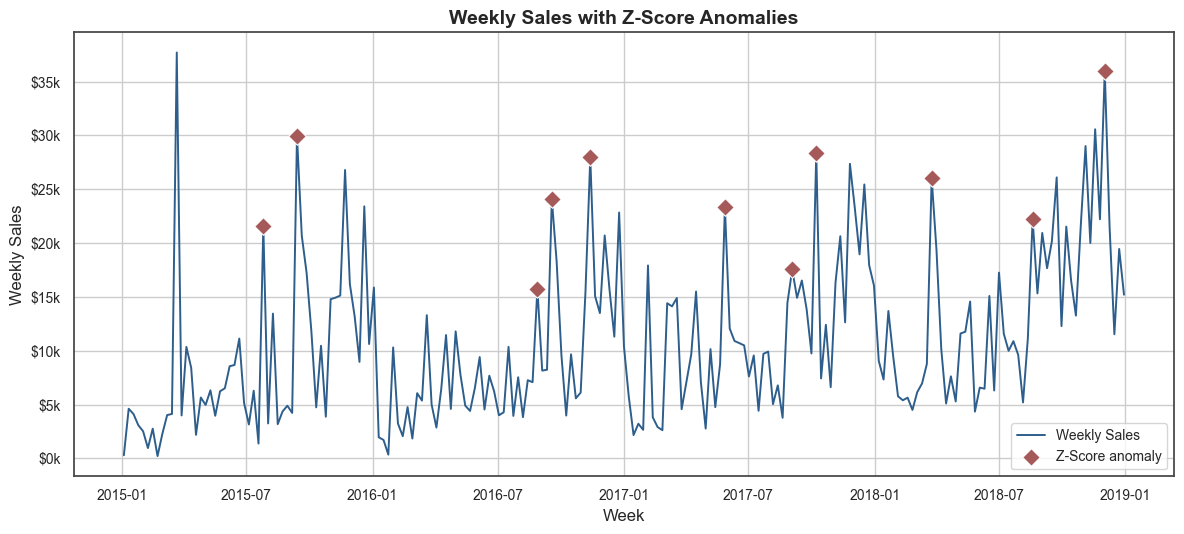

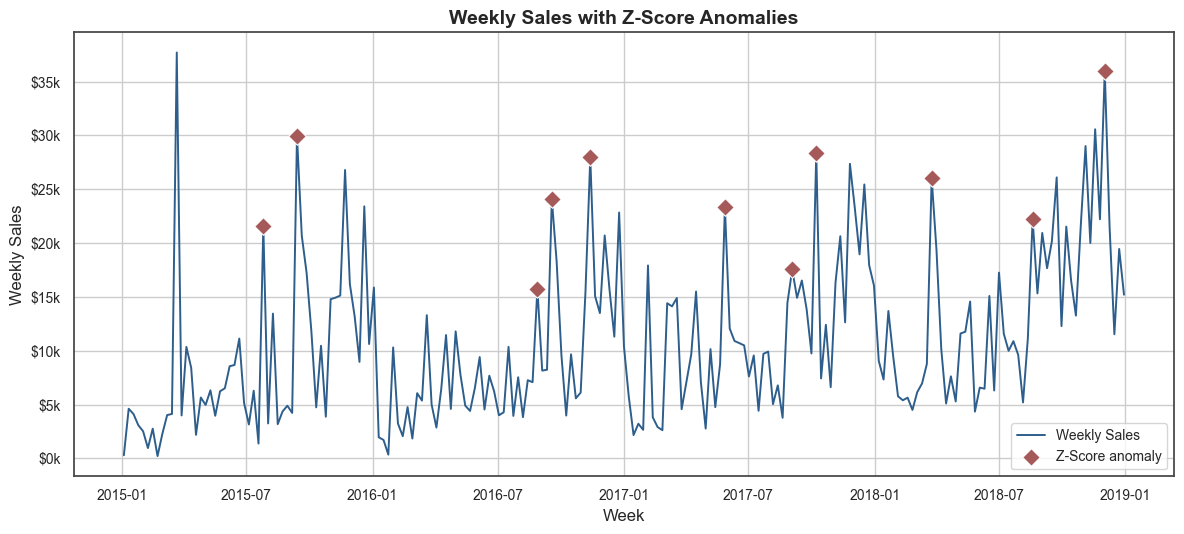

In [52]:
zscore_fig = charts.plot_weekly_anomalies(weekly_sales, zscore_flags, "Z-Score")
save_figure(zscore_fig, "weekly_zscore_anomalies.png")
zscore_fig

Worth noting: the $37,704 week of 2015-03-22, the single largest dollar week in the entire
four-year series, isn't marked here at all. It falls inside the 13-week burn-in period, so the
Z-score method simply can't evaluate it, no matter how extreme it is. That's a concrete
illustration of the method's main blind spot, and it comes up again in the comparison below.

### 5.3 Method 2 — Isolation Forest

Isolation Forest needs feature columns rather than a raw series, so two are built: `sales`,
the raw weekly level, which catches weeks that are extreme in absolute dollars, and
`pct_change_1w`, the week-over-week percentage change, which catches sudden shocks that a
smoothed level alone would either miss or over-weight when the swing happens off a small base.
The two turn out to be only weakly correlated on this data, checked below, so combining them
gives the model two genuinely different axes of "unusual" instead of counting the same signal
twice.

In [53]:
if_features = ad.build_isolation_forest_features(weekly_sales)
print(f"Feature correlation (should be low — otherwise one feature is redundant):")
if_features.corr().round(2)

Feature correlation (should be low — otherwise one feature is redundant):


,sales,pct_change_1w
sales,1.00,0.19
pct_change_1w,0.19,1.00


A few parameters here are worth explaining rather than leaving at their defaults. The
contamination rate is set to 0.05, close to the 4.55% two-sided tail probability of the same
2-sigma threshold used for the Z-score method — matching the two methods' expected anomaly
rate means any difference in which weeks they flag reflects a genuine methodological
disagreement, not one method simply being configured more loosely than the other. The number
of estimators is left at 100, verified empirically below rather than just assumed: at a fixed
random state, the flagged set doesn't change between 100, 200, and 500 trees, so the sklearn
default already gives a stable result on this 208-row dataset. `max_samples` resolves to
`min(256, n_samples) = 208`, meaning every tree already sees the full dataset, so there's
nothing to tune there. The random state is fixed at 42 for reproducibility, since Isolation
Forest's tree construction involves randomised feature and split-point selection — the same
seed used for XGBoost in Task 3. And both features are standardised before fitting, since
`sales` in dollars and `pct_change_1w` as a ratio live on very different scales, and
standardising keeps them contributing comparably once combined.

In [54]:
_, baseline_flags, _ = ad.fit_isolation_forest(if_features, n_estimators=100)
for n_estimators in (100, 200, 500):
    _, trial_flags, _ = ad.fit_isolation_forest(if_features, n_estimators=n_estimators)
    print(f"n_estimators={n_estimators:3d}: {trial_flags.sum()} weeks flagged "
          f"(identical set vs. n_estimators=100: {trial_flags.equals(baseline_flags)})")

n_estimators=100: 11 weeks flagged (identical set vs. n_estimators=100: True)


n_estimators=200: 11 weeks flagged (identical set vs. n_estimators=100: True)


n_estimators=500: 11 weeks flagged (identical set vs. n_estimators=100: True)


Weeks flagged: 11 of 208 scored (only the first week is unscored — one lag needed for pct_change)


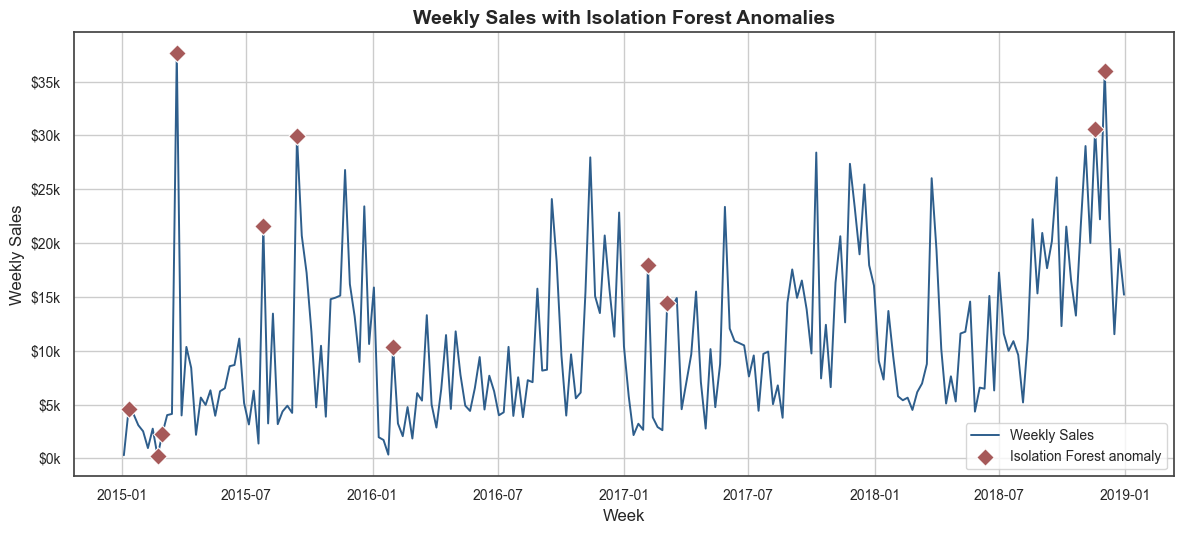

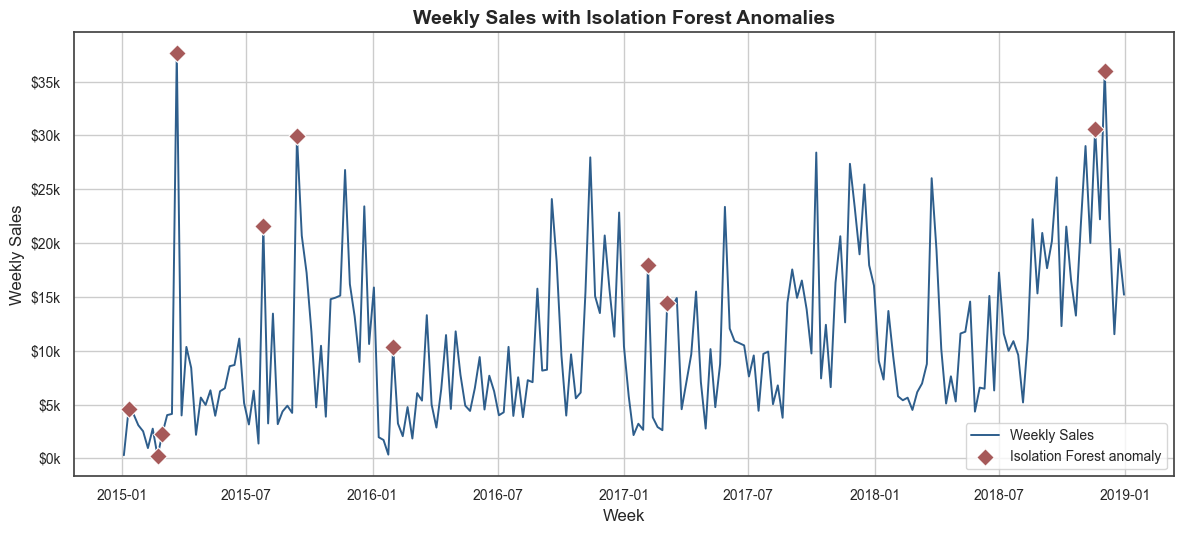

In [55]:
if_model, if_flags, if_scores = ad.fit_isolation_forest(if_features)
print(f"Weeks flagged: {if_flags.sum()} of {len(if_features)} scored "
      f"(only the first week is unscored — one lag needed for pct_change)")

if_fig = charts.plot_weekly_anomalies(weekly_sales, if_flags, "Isolation Forest")
save_figure(if_fig, "weekly_isolation_forest_anomalies.png")
if_fig

Unlike the Z-score chart, this one does mark the March 2015 week at $37,704 — Isolation Forest
only needs a single week of lag history for `pct_change_1w`, so it can evaluate almost the
entire series, including the stretch that Z-score's 13-week burn-in has to skip.

### 5.4 Evidence and business interpretation for every detected anomaly

Rather than just asserting an explanation for each flagged week, the context needed to support
one gets computed directly: the order-line count and average order value (which distinguish a
broad-based demand surge from a handful of large, concentrated orders), and a generic
retail-calendar note for that month. No anomaly date is hardcoded anywhere in this pipeline —
every row below is a week that one of the two models actually flagged.

In [56]:
evidence = ad.anomaly_evidence_table(weekly_sales, order_lines, zscore_flags, if_flags)
evidence

,Sales,Order Lines,Avg Order Value,WoW % Change,Flagged By,Demand Driver,Retail Calendar Context
Week,,,,,,,
2015-01-11,"4,619.00",17,272.00,"1,417.00",Isolation Forest,concentrated (few large orders),January — post-holiday lull and New Year clear...
2015-02-22,225.00,10,22.00,-92.00,Isolation Forest,mixed / inconclusive,February — Presidents' Day promotions
2015-03-01,"2,290.00",15,153.00,918.00,Isolation Forest,mixed / inconclusive,March — spring / end-of-Q1 corporate purchasin...
2015-03-22,"37,704.00",54,698.00,811.00,Isolation Forest,mixed / inconclusive,March — spring / end-of-Q1 corporate purchasin...
2015-07-26,"21,590.00",60,360.00,"1,456.00","Z-Score, Isolation Forest",broad-based (many orders),July — mid-summer clearance and Independence D...
2015-09-13,"29,959.00",97,309.00,607.00,"Z-Score, Isolation Forest",broad-based (many orders),September — Labor Day sales and continued back...
2016-01-31,"10,315.00",12,860.00,"2,777.00",Isolation Forest,concentrated (few large orders),January — post-holiday lull and New Year clear...
2016-08-28,"15,773.00",47,336.00,123.00,Z-Score,mixed / inconclusive,August — back-to-school shopping ramp-up
2016-09-18,"24,096.00",76,317.00,192.00,Z-Score,broad-based (many orders),September — Labor Day sales and continued back...


Reading the evidence table by pattern — every claim below traces back to a specific row, not
a general impression — the three weeks both methods agree on are 2015-07-26 ($21.6k),
2015-09-13 ($30.0k), and 2018-12-02 ($36.0k). All three are classified broad-based, with
order-line counts of 60, 97, and 126 respectively, comfortably above the series median. These
read as genuine demand surges rather than statistical artefacts, and they line up neatly with
the retail calendar: July clearance, the September back-to-school and Labor Day period Task 2
already flagged as the largest residual, and the Cyber Monday-to-Christmas peak.

Five weeks flagged only by Isolation Forest fall in early 2015 or January 2016, and the
order-line evidence actually splits them into two different stories rather than one.
2015-01-11 (17 lines against a 42-line median, $272 average order value against $206) and
2016-01-31 (12 lines, $860 average order value) are genuinely concentrated — low order counts
paired with an above-median average order value, consistent with one or two sizeable
transactions landing in an otherwise quiet week rather than any broad shift in demand.
2015-02-22 (10 lines, a $22 average order value) and 2015-03-01 (15 lines, $153) are
mixed or inconclusive for the opposite reason: both order count and average order value sit
below the median. These look like ordinary quiet weeks from the business's low-volume 2015
ramp-up period, flagged mainly because the percentage-change feature reacts strongly to any
swing off an already tiny base, not because anything unusual actually happened. The exception
in this group is 2015-03-22, the series' all-time-high week at $37,704 — its 54 order lines
sit above the 42-line median, which rules out the strict "few large orders" pattern, but its
$698 average order value is still more than three times the $206 median, so the record week
looks driven by unusually large transaction sizes layered on top of slightly-above-typical
volume, not by broad customer demand alone.

Most of the weeks flagged only by Z-score, from 2016 onward, are broad-based: six of the eight
— 2016-09-18, 2016-11-13, 2017-05-28, 2017-09-03, 2018-03-25, and 2018-08-19 — have order-line
counts clearly above the median. These are genuine, moderate demand elevations that a 13-week
local baseline is sensitive enough to catch, even though they weren't extreme enough in
absolute dollars or week-over-week percentage terms to trip Isolation Forest's contamination
budget. Several line up with recognisable retail moments — 2016-11-13 sits just before
Thanksgiving, 2017-09-03 is Labor Day, 2018-03-25 is an end-of-quarter week. The other two are
worth naming rather than glossing over: 2016-08-28 is mixed or inconclusive, with 47 lines
close to the 42-line median and no clear driver in either direction, and 2017-10-08 is
concentrated, with only 35 lines but an $812 average order value, closer in profile to the
few-large-orders pattern seen above.

One more week stands out on its own: 2018-11-18, at $30.6k and 117 order lines — the second-
highest order-line count in the table — is flagged only by Isolation Forest despite being
clearly broad-based. Its z-score of 1.82 fell just short of the 2.0 threshold, a genuine
near-miss for the Z-score rule that comes up again in the comparison below.

### 5.5 Comparing the two methods

Only 3 of the 19 total flagged weeks, or 16%, are flagged by both methods — which makes sense,
given the two work from different information (a smoothed local baseline versus level plus
week-over-week shock) and different decision rules (a fixed statistical threshold versus a
budgeted proportion). All three are consistently broad-based, and they rank in the upper half
of flagged weeks by dollar value — 2018-12-02 is the second-highest of the 19, 2015-09-13 the
fourth, 2015-07-26 the eleventh — though none of them is the single largest. The two most
extreme weeks in raw dollars, 2015-03-22 at $37.7k and 2018-11-18 at $30.6k, are each flagged
by only one method: the former is order-line-ambiguous, as covered in §5.4, and the latter is
a near-miss for Z-score at z = 1.82. So agreement between the two methods isn't simply about
picking the biggest weeks — it favours weeks that are unambiguously broad-based in their
order-line profile, which is still a reassuring convergence on the clearest cases, just not a
purely dollar-ranked one.

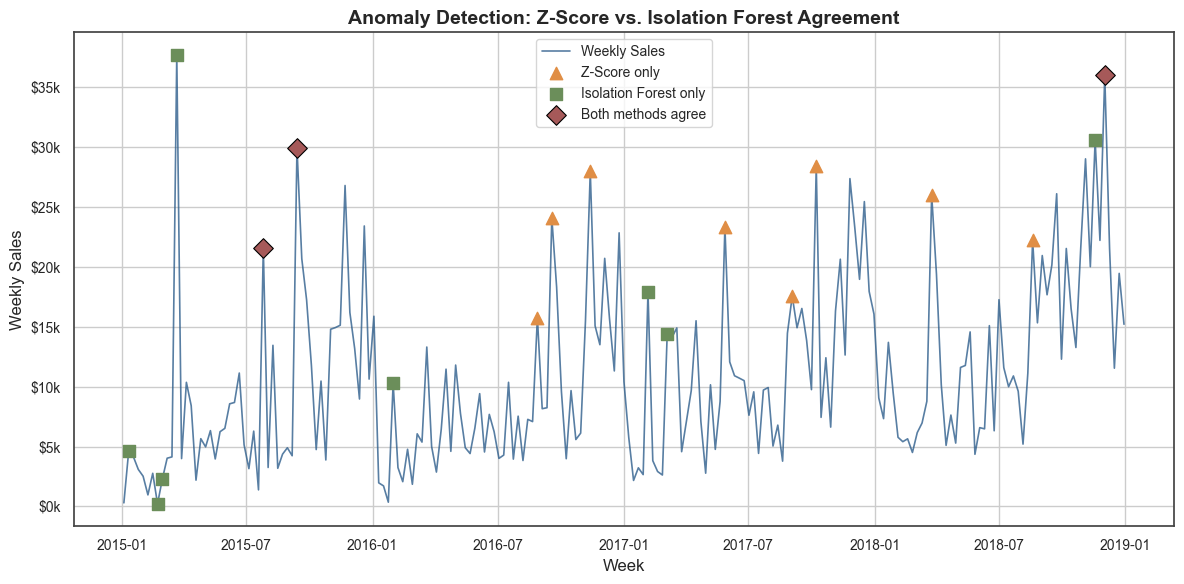

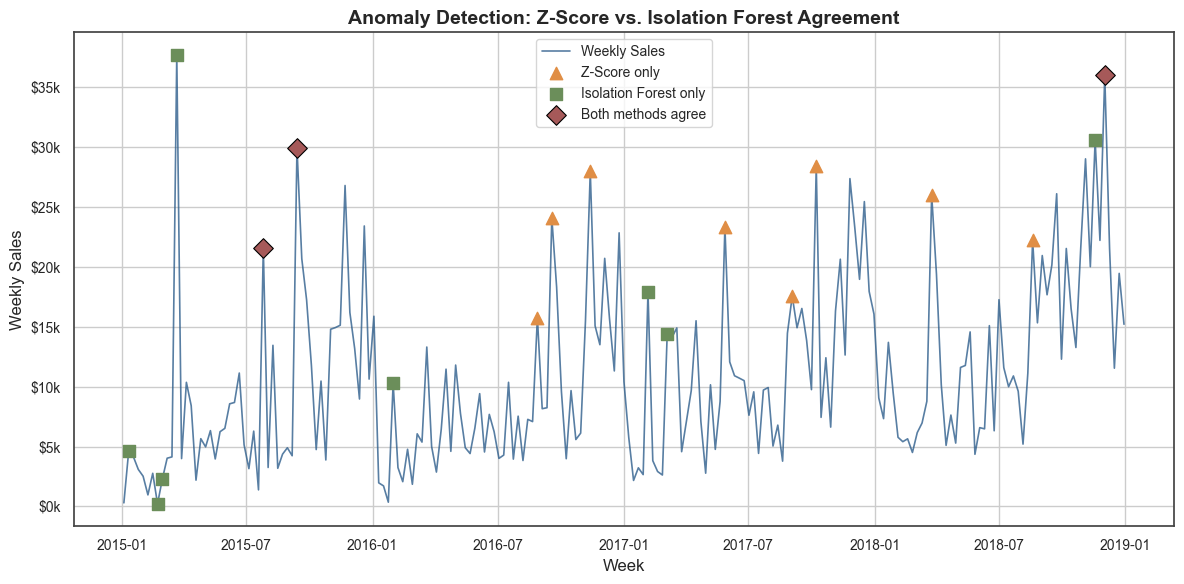

In [57]:
comparison_fig = charts.plot_anomaly_method_comparison(weekly_sales, zscore_flags, if_flags)
save_figure(comparison_fig, "anomaly_method_comparison.png")
comparison_fig

The disagreements are just as informative as the agreements. Isolation Forest catches what
Z-score structurally cannot: the 13-week burn-in means Z-score can never evaluate the first
quarter of the series, including the single largest dollar week in the whole dataset
(2015-03-22), while Isolation Forest needs only a one-week lag and has no such blind spot.
Z-score, in turn, catches sustained-but-moderate deviations that Isolation Forest's budget
excludes — with contamination fixed at 5%, Isolation Forest can only ever flag its most
extreme 5% of weeks, so several 2016-2018 weeks that clear the statistical 2-sigma bar simply
rank outside its fixed quota. Isolation Forest is also more sensitive to a low base: its
percentage-change feature flagged several early-2015 and early-2016 weeks driven by swings off
a very small prior week, which looks more like a data artefact of the business's ramp-up
period than a meaningful anomaly. And Z-score turns out to be more sensitive to the window
choice than Isolation Forest is to its tree count — the flagged count more than doubles, from
6 to 14, across the candidate windows in §5.2, whereas Isolation Forest's flagged count stayed
identical across a fivefold range of `n_estimators`.

Put side by side, the two methods trade off cleanly:

| | Z-score | Isolation Forest |
| --- | --- | --- |
| Interpretability | High — "N standard deviations from a 13-week average" is directly explainable to a non-technical stakeholder | Lower — an ensemble anomaly score is harder to explain in one sentence |
| Burn-in / data coverage | Loses the first 13 weeks entirely | Loses only 1 week (needs a single lag) |
| Sensitivity control | A statistically motivated threshold (2-sigma) | A pre-specified contamination rate, which assumes you already know roughly how many anomalies to expect |
| Captures multivariate shocks | No — a single dimension (deviation from level) | Yes — level and rate-of-change jointly |
| Sensitive to parameter choice | Window size materially changes results (3.0%-7.6% flag rate across candidates) | Stable across a 5x range of `n_estimators` at fixed contamination |

### 5.6 Production recommendation

Neither method dominates the other on every axis, so the right question isn't which one wins
but which role each should play. Z-score makes sense as the primary, stakeholder-facing
detector: in a production retail analytics system, the audience for an anomaly alert is often
a business manager rather than a data scientist, and "this week's sales were N standard
deviations above the trailing 13-week average" is immediately understandable, cheap to
recompute every week, and needs no model retraining. Its two structural weaknesses — the
13-week burn-in and its sensitivity to the window choice — are both tolerable in steady-state
production, since a live system accumulates far more than 13 weeks of history over time.

Isolation Forest works better as a complementary check, particularly useful during the first
quarter of any new product, region, or store's history, where Z-score can't yet score
anything, and for catching multivariate shocks — a sudden rate-of-change event — that a
single-dimension rolling statistic isn't built to see.

Operationally, the evidence in the last two sections supports a simple tiered alert: weeks
both methods flag, only three here, and consistently the unambiguous broad-based demand
events, get treated as the highest-confidence, highest-priority alerts. Weeks flagged by only
one method are lower priority and worth a lighter-touch review rather than an immediate
escalation — including the single largest dollar week in the series, 2015-03-22, which is
exactly the kind of single-method, ambiguous-driver case that merits a human look rather than
an automatic high-severity flag. That approach uses what each method is actually good at
instead of discarding either one.

## Task 6 — Product Demand Segmentation using Clustering

The last analytical task groups the 17 product sub-categories into demand segments using
K-Means, so stocking policy can be set per segment instead of negotiated product by product.
Each sub-category gets reduced to four features covering scale, trend, stability, and price
positioning; K-Means is fit on the standardised versions of those features; and the number of
clusters comes from the Elbow Method and the Silhouette Score rather than a guess. PCA appears
only to render the result in two dimensions for the scatter plot later in this section — it
plays no role in forming the clusters themselves.

### 6.1 Feature engineering at the sub-category level

Four features get built, each answering a distinct business question: `TotalSales` (four-year
total revenue) asks how big the sub-category is; `MeanYoYGrowth` (the mean of the three
year-over-year percentage changes from 2015 to 2018) asks whether it's growing or shrinking;
`MonthlyVolatilityCV`, the coefficient of variation of monthly sales, asks how erratic its
demand is relative to its own scale; and `AvgOrderValue` (total sales divided by order-line
count) asks whether it's a high-ticket or low-ticket line.

In [58]:
subcategory_features = cl.build_subcategory_features(sales, monthly_series.index)
subcategory_features

,TotalSales,MeanYoYGrowth,MonthlyVolatilityCV,AvgOrderValue,OrderLines
Sub-Category,,,,,
Accessories,"164,186.70",37.64,0.75,217.18,756
Appliances,"104,618.40",39.93,0.84,227.93,459
Art,"26,705.41",16.61,0.59,34.02,785
Binders,"200,028.79",21.87,0.92,134.07,1492
Bookcases,"113,813.20",23.81,0.94,503.60,226
Chairs,"322,822.73",7.14,0.66,531.83,607
Copiers,"146,248.09",84.67,1.63,"2,215.88",66
Envelopes,"16,128.05",-2.77,0.70,65.03,248
Fasteners,"3,001.96",15.70,0.78,14.03,214


The volatility feature deserves a closer look, since the task literally names "standard
deviation of monthly sales" and that's checked first, not skipped. It turns out to correlate
strongly with `TotalSales` on this data, which would make it a near-duplicate of the volume
feature rather than genuinely new information once both are standardised for K-Means.

In [59]:
raw_monthly_std = cl.raw_monthly_std_by_subcategory(sales, monthly_series.index)
std_vs_volume_corr = raw_monthly_std.corr(subcategory_features["TotalSales"])
print(f"Correlation between raw monthly $ std and TotalSales: {std_vs_volume_corr:.2f}")

Correlation between raw monthly $ std and TotalSales: 0.82


A 0.82 correlation confirms that suspicion — the raw dollar standard deviation mostly just
restates `TotalSales`, since a large sub-category naturally swings by more dollars even if
it's no more erratic relative to its own size. The coefficient of variation, computed inside
`build_subcategory_features` as `MonthlyVolatilityCV`, divides out the scale and isolates
genuine relative volatility as a feature distinct from volume — exactly the "low volume, high
volatility" versus "high volume, stable demand" distinction the task's example labels are
pointing at.

### 6.2 Preprocessing: transform and scale

Two preprocessing decisions get made here, and both are checked against the data rather than
applied by default.

In [60]:
total_sales_skew_before, total_sales_skew_after = cl.skewness_before_after_log(subcategory_features["TotalSales"])
avg_order_skew_before, avg_order_skew_after = cl.skewness_before_after_log(subcategory_features["AvgOrderValue"])

print("Skewness before/after log1p transform:")
print(f"  TotalSales:     raw={total_sales_skew_before:.2f}  log1p={total_sales_skew_after:.2f}  "
      f"(transform NOT applied — makes skew worse)")
print(f"  AvgOrderValue:  raw={avg_order_skew_before:.2f}  log1p={avg_order_skew_after:.2f}  "
      f"(transform applied — corrects the skew)")

Skewness before/after log1p transform:
  TotalSales:     raw=0.49  log1p=-1.15  (transform NOT applied — makes skew worse)
  AvgOrderValue:  raw=2.08  log1p=-0.04  (transform applied — corrects the skew)


`AvgOrderValue` is right-skewed, driven mainly by Copiers' $2,216 average against a $206
median across the other categories, and a log1p transform clearly corrects it, so it gets
log-transformed. `TotalSales` is only mildly skewed to begin with, and log-transforming it
actually makes the skew worse — so it's deliberately left alone rather than log-transforming
every monetary feature out of habit. All four features are then standardised to zero mean and
unit variance, since they sit on incomparable scales — dollars in the hundreds of thousands, a
percentage, a ratio near 1, and log-dollars — and K-Means' Euclidean distance would otherwise
be dominated by whichever feature happens to have the largest raw numeric range.

In [61]:
clustering_features, X_scaled = cl.prepare_clustering_features(subcategory_features)
clustering_features

,TotalSales,MeanYoYGrowth,MonthlyVolatilityCV,AvgOrderValueLog
Sub-Category,,,,
Accessories,"164,186.70",37.64,0.75,5.39
Appliances,"104,618.40",39.93,0.84,5.43
Art,"26,705.41",16.61,0.59,3.56
Binders,"200,028.79",21.87,0.92,4.91
Bookcases,"113,813.20",23.81,0.94,6.22
Chairs,"322,822.73",7.14,0.66,6.28
Copiers,"146,248.09",84.67,1.63,7.70
Envelopes,"16,128.05",-2.77,0.70,4.19
Fasteners,"3,001.96",15.70,0.78,2.71


### 6.3 Choosing the number of clusters

Both the Elbow Method and the Silhouette Score get computed across a range of candidate `k`
values, rather than settling on one number arbitrarily.

In [62]:
cluster_search_result = cl.cluster_search(X_scaled, k_range=range(2, 9))
cluster_search_result

,inertia,silhouette_score
k,,
2,40.98,0.45
3,19.05,0.43
4,11.92,0.42
5,7.40,0.42
6,5.54,0.38
7,4.17,0.31
8,2.90,0.28


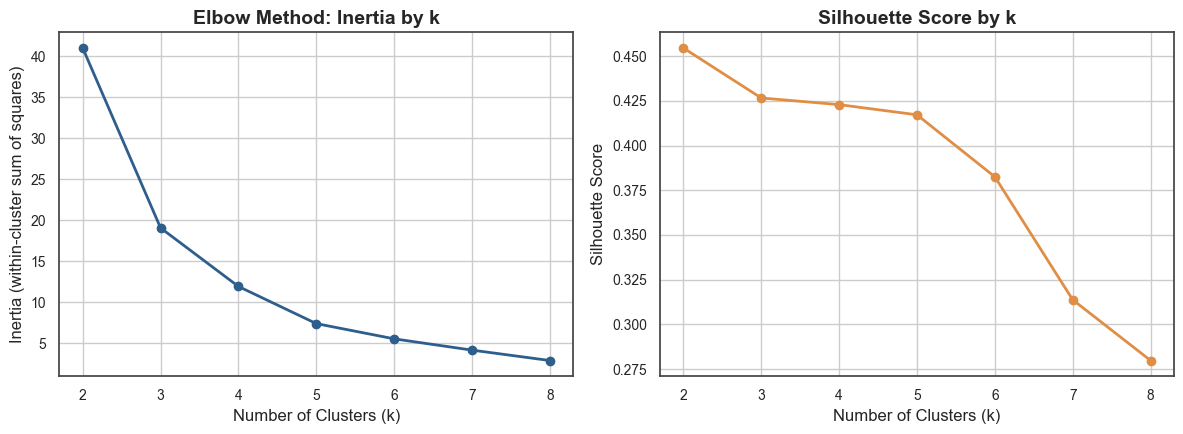

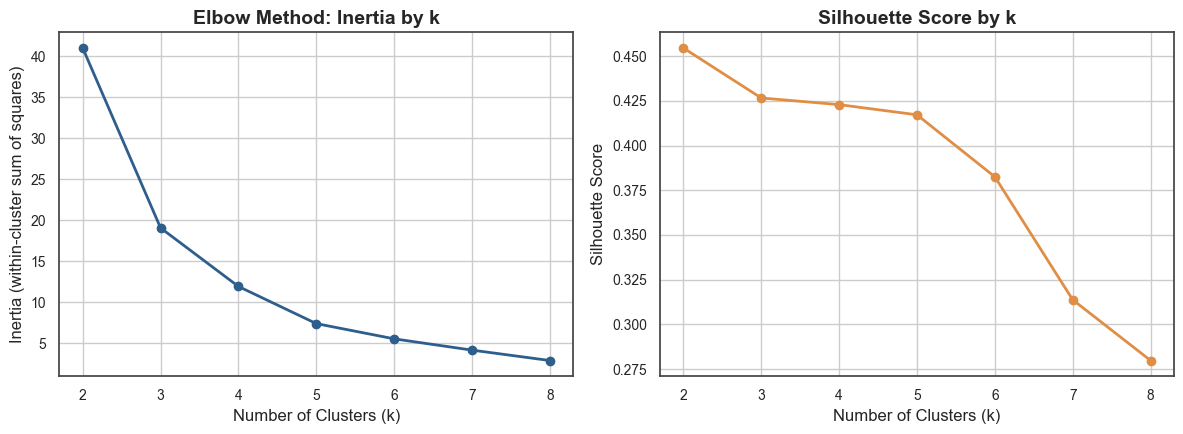

In [63]:
elbow_fig = charts.plot_cluster_search(cluster_search_result)
save_figure(elbow_fig, "cluster_elbow_silhouette.png")
elbow_fig

The inertia curve bends sharply between k=2 and k=4 and then flattens out, so diminishing
returns set in around k=4. The silhouette score is highest at k=2 (0.45) and decreases roughly
monotonically after that, but only marginally between k=3 (0.427), k=4 (0.423), and k=5
(0.417) — essentially flat across that range before dropping off more sharply from k=6
onward. With only 17 sub-categories, k=2 is too coarse to be useful, amounting to little more
than a big-versus-small split, while the silhouette evidence shows k=3 through k=5 are
statistically almost indistinguishable from one another. That makes interpretability the
deciding factor: at k=4, the resulting clusters separate into four genuinely distinct business
profiles, including isolating the one sub-category with an extreme, unrepeated growth pattern,
whereas k=3 merges that outlier into a group it doesn't otherwise resemble. Four clusters is
the number carried forward.

### 6.4 Fitting K-Means and profiling the clusters

In [64]:
kmeans_model = cl.fit_kmeans(X_scaled, n_clusters=4)
cluster_labels = pd.Series(kmeans_model.labels_, index=subcategory_features.index, name="Cluster")

cluster_profile = cl.cluster_profile(subcategory_features, kmeans_model.labels_)
cluster_profile

,TotalSales,MeanYoYGrowth,MonthlyVolatilityCV,AvgOrderValue,Sub-Categories,n
Cluster,,,,,,
0,"37,370.58",15.99,0.72,50.15,"Art, Envelopes, Fasteners, Furnishings, Labels...",6
1,"206,925.79",21.54,0.76,362.29,"Accessories, Appliances, Binders, Bookcases, C...",8
2,"46,420.31",192.84,2.03,252.28,Supplies,1
3,"167,743.36",46.34,1.50,"1,930.72","Copiers, Machines",2


In [65]:
# Revenue share per cluster: cluster mean x member count, as a percentage of the
# business-wide four-year total — referenced directly in the cluster interpretations below.
cluster_total_sales = cluster_profile["TotalSales"] * cluster_profile["n"]
cluster_revenue_share = (cluster_total_sales / subcategory_features["TotalSales"].sum() * 100).round(1)
cluster_revenue_share.rename("Revenue Share %")

Cluster
0    9.90
1   73.20
2    2.10
3   14.80
Name: Revenue Share %, dtype: float64

### 6.5 PCA — for visualization only

It's worth being explicit here: this PCA step is not part of the clustering. K-Means above was
fit on the full four-dimensional standardised feature space, and PCA is applied afterwards
purely to compress that same space into two dimensions so the already-formed clusters can be
plotted. No cluster assignment, profile statistic, or business recommendation anywhere in this
notebook is derived from the PCA components — they exist only to make the chart below possible.

In [66]:
pca_coords, pca_model = cl.pca_projection(X_scaled, subcategory_features.index)
print(f"Variance explained: PC1={pca_model.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca_model.explained_variance_ratio_[1]:.1%}, "
      f"cumulative={pca_model.explained_variance_ratio_.sum():.1%}")
pd.DataFrame(pca_model.components_.T, index=clustering_features.columns, columns=["PC1", "PC2"]).round(2)

Variance explained: PC1=51.0%, PC2=40.5%, cumulative=91.6%


,PC1,PC2
TotalSales,0.04,0.75
MeanYoYGrowth,0.61,-0.28
MonthlyVolatilityCV,0.67,-0.16
AvgOrderValueLog,0.43,0.58


The two components capture 91.6% of the standardised feature variance, so very little is lost
in the projection. PC1 is dominated by `MeanYoYGrowth` and `MonthlyVolatilityCV`, effectively
a growth-and-volatility axis, while PC2 is dominated by `TotalSales` and `AvgOrderValueLog`, a
scale-and-value axis — the scatter plot below can be read along those two intuitive
directions.

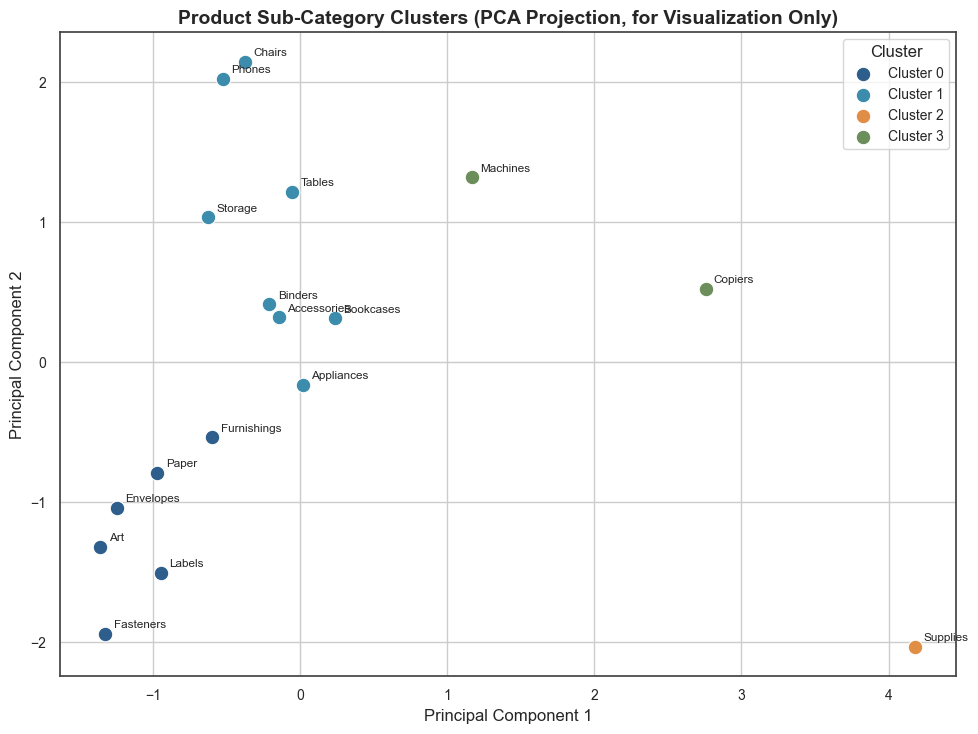

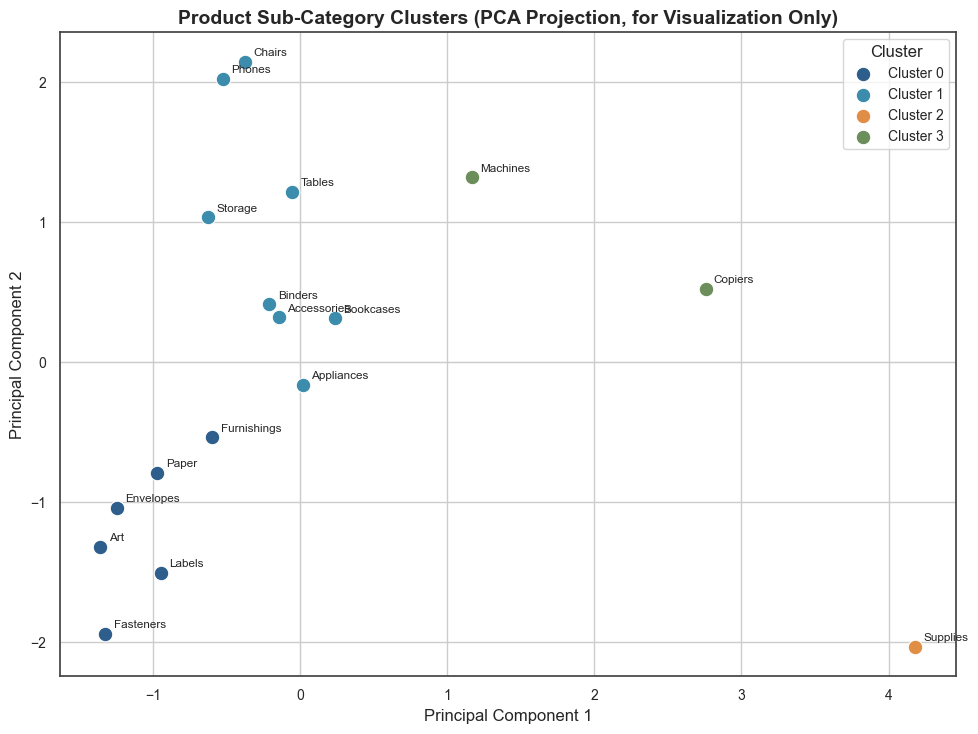

In [67]:
pca_fig = charts.plot_pca_clusters(pca_coords, cluster_labels)
save_figure(pca_fig, "cluster_pca_scatter.png")
pca_fig

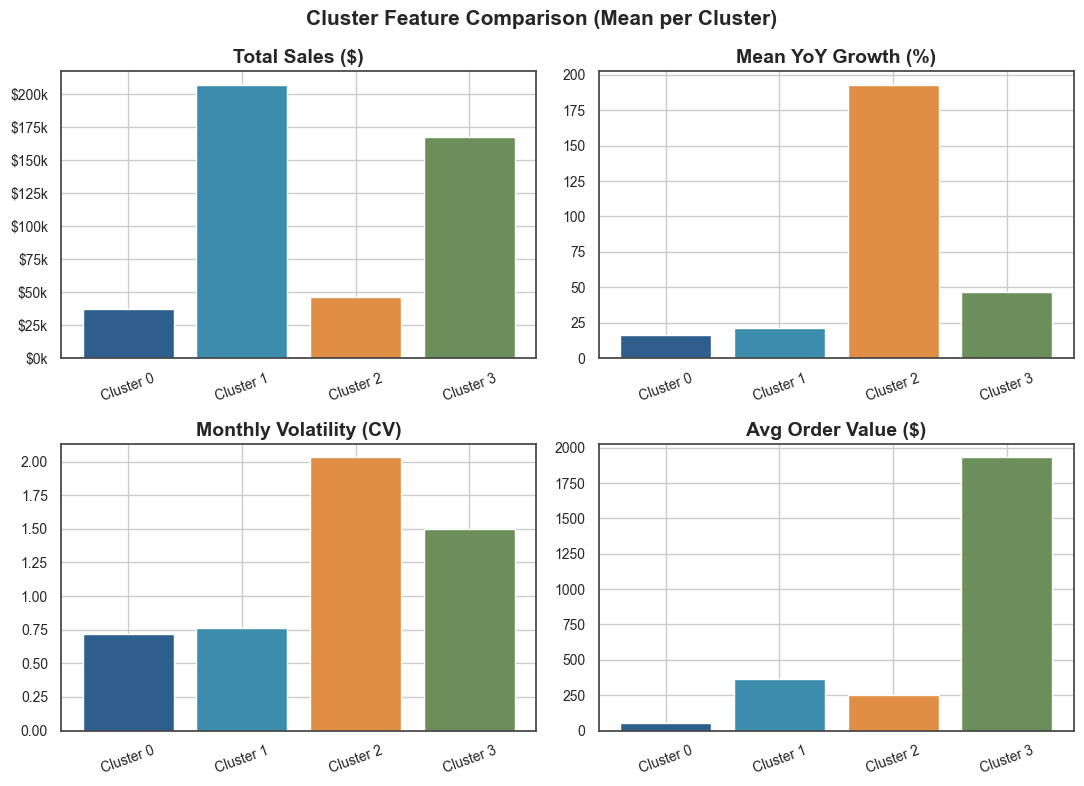

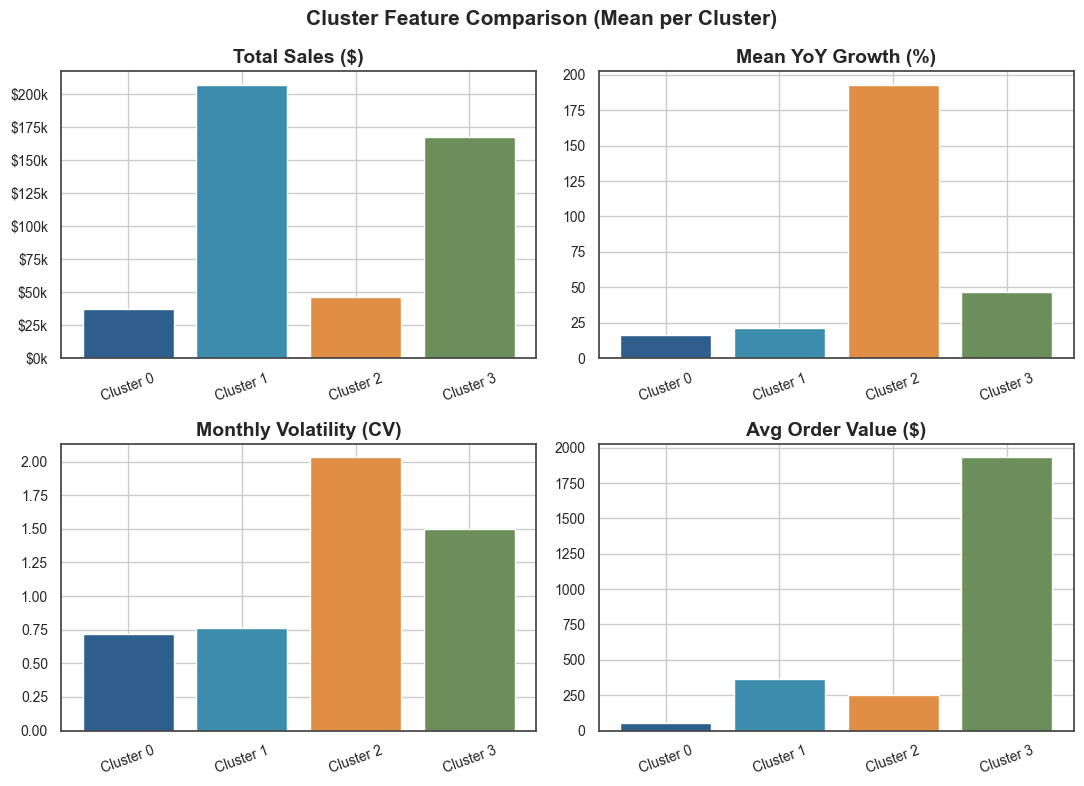

In [68]:
feature_comparison_fig = charts.plot_cluster_feature_comparison(cluster_profile)
save_figure(feature_comparison_fig, "cluster_feature_comparison.png")
feature_comparison_fig

### 6.6 Supporting evidence for the interpretations below

Two numbers referenced in the cluster write-ups below are worth computing explicitly here
rather than leaving as unsupported claims in the prose: the business-wide median order-line
count per sub-category, used to characterise Cluster 3 as low-frequency, and the annual sales
history behind Cluster 2's unusually large growth figure.

In [69]:
print(f"Median order lines per sub-category: {subcategory_features['OrderLines'].median():.0f}")
print(f"Copiers: {subcategory_features.loc['Copiers', 'OrderLines']:.0f} lines  |  "
      f"Machines: {subcategory_features.loc['Machines', 'OrderLines']:.0f} lines")

Median order lines per sub-category: 459
Copiers: 66 lines  |  Machines: 115 lines


In [70]:
supplies_annual = (
    sales[sales["Sub-Category"] == "Supplies"]
    .groupby(sales["Order Date"].dt.year)["Sales"].sum()
)
supplies_annual.rename("Supplies Annual Sales ($)").round(0)

Order Date
2015   14,336.00
2016    1,891.00
2017   14,242.00
2018   15,952.00
Name: Supplies Annual Sales ($), dtype: float64

Supplies fell from $14,336 in 2015 to $1,891 in 2016, an 87% collapse, then rebounded to
$14,242 in 2017 and $15,952 in 2018. That single rebound year between 2016 and 2017 is what
dominates the three-year mean growth figure reported in the profile table — the number is
technically correct, but it tells a very different story from steady expansion.

### 6.7 Cluster interpretation and stocking recommendations

Each label below comes directly from the statistics in the profile table above. None of the
task's example labels are applied by default — they're used only where the computed numbers
genuinely support them.

#### Cluster 1 — "High Volume, Stable Demand"
n = 8: Accessories, Appliances, Binders, Bookcases, Chairs, Phones, Storage, Tables

This is by far the largest cluster by revenue — $206,926 in average total sales per
sub-category, more than any other group — combined with moderate growth (+21.5% mean YoY) and
the lowest-to-second-lowest volatility of the four clusters (CV = 0.76, essentially tied with
Cluster 0's 0.72). That's the classic combination of scale and predictability, and together
these 8 sub-categories account for 73.2% of the business's total four-year revenue. In plain
terms, this is the revenue backbone: high-selling, dependably-selling product lines.

Predictable, high-volume demand is exactly what automated replenishment systems are built for.
This cluster should get priority warehouse space, moderate safety stock sized to its modest
volatility, and automated reorder-point policies — the low CV means stockout risk here is
manageable without holding excessive buffer inventory.

#### Cluster 0 — "Low Volume, Stable Demand"
n = 6: Art, Envelopes, Fasteners, Furnishings, Labels, Paper

This cluster has the lowest total sales of the four ($37,371 average), moderate growth
(+16.0%), the lowest volatility of any cluster (CV = 0.72), and by far the lowest average
order value at $50. In business terms, these are low-revenue, low-ticket items with stable,
predictable — if modest — demand. Not a priority for growth investment, but not a risk either.

Lean, low safety-stock inventory is the right call here. With volatility this low, a simple
min-max reorder policy is enough, and there's no case for tying up working capital in large
buffer stock when demand rarely strays far from its own average.

#### Cluster 3 — "High-Value, Growing Demand"
n = 2: Copiers, Machines

The standout number here is average order value: $1,931, which is 5.3 times Cluster 1's,
7.7 times Cluster 2's, and 38.5 times Cluster 0's. That's driven by genuinely low order-line
counts — Copiers at 66 lines, Machines at 115, against a business-wide median of 459 lines per
sub-category — combined with above-average growth (+46.3% mean YoY) and elevated volatility
(CV = 1.50, second-highest of the four clusters). This is the classic big-ticket,
infrequent-purchase profile: few transactions, each one large, with a genuine growth trend
rather than a stable base.

Holding large physical inventory of expensive, infrequently-sold items ties up capital that
this demand pattern can't absorb. A low-stock or make-to-order / drop-ship model makes more
sense, with supplier lead times short enough to keep up as demand grows, rather than the
standing safety stock that suits Clusters 0 and 1.

#### Cluster 2 — "Volatile, High-Growth Outlier"
n = 1: Supplies

Supplies didn't group naturally with anything else and ended up in a cluster of its own — by
a wide margin the highest mean YoY growth of any sub-category (+192.8%, with Copiers a distant
second at 84.7%) and the highest volatility (CV = 2.03). As shown in §6.6, that growth figure
isn't steady expansion; it's a single collapse-then-rebound swing, down 87% in 2016 and up 653%
in 2017, that dominates the three-year average.

This isn't a "growing demand" story in the steady sense Cluster 3 represents — it's one
sub-category with a volatile, boom-bust history that happens to average out to a large
positive number. A cluster of one also means there's no within-cluster variance to lean on, so
this is better treated as a flagged product line for manual review than a policy-driven
segment.

Given the swing between near-collapse and rapid rebound, a static safety-stock policy would be
a poor fit — it would either stock out during a collapse or sit on excess inventory through a
slow period. Short-cycle, demand-sensing replenishment, smaller and more frequent orders, and
a dedicated analyst keeping an eye on this sub-category specifically make more sense than
applying any cluster-wide rule.

Stepping back, this task engineered four features per sub-category, checked rather than
assumed two preprocessing calls — replacing the raw dollar standard deviation with a
coefficient of variation, and log-transforming only the genuinely skewed average-order-value
feature — and settled on four clusters using the Elbow Method and Silhouette Score together,
with interpretability breaking the tie once the two metrics converged on a similar answer.
PCA played no role beyond the 2D visualisation. What came out the other side were four
genuinely distinct, evidence-backed segments: the high-volume backbone, a low-volume but
stable tier, a high-value low-frequency group with real growth, and one volatile outlier whose
headline growth number turned out to be a single boom-bust year rather than a trend. Each one
got a stocking recommendation grounded in its own numbers, not a one-size-fits-all policy.

## Task 7 — Deployment: Interactive Dashboard using Streamlit

The interactive dashboard is a separate Streamlit application rather than notebook output —
that's a deliberate choice, since a dashboard meant to be clicked through by a business user
doesn't belong inside a Jupyter notebook. It lives in `app.py` at the project root, with the
supporting code organised under `src/dashboard/` (page views, chart builders, and a small
design system) and `src/dashboard/artifacts.py`, which precomputes every forecast, anomaly
flag, and cluster assignment the dashboard displays so the app itself never re-runs any model.

The app has seven pages: an Executive Overview with headline KPIs and a plain-language
summary; Sales Analytics, with interactive filters over the processed line-item data;
Forecasting, where SARIMA, Prophet, and XGBoost can be compared side by side with their
hold-out and backtest metrics; Segment Forecasts for the five category and region breakdowns
from Task 4; Anomaly Detection, switching between the Z-score and Isolation Forest views from
Task 5; Product Clustering, with the PCA scatter and per-cluster stocking guidance from Task 6;
and an About page covering the project's methodology and technology stack. Run it locally with
`streamlit run app.py`.

## Task 8 — Executive Business Report

The executive report is a separate document rather than a notebook section, since its intended
reader is a business stakeholder — the Head of Supply Chain, the CFO — not someone reading
Python output. It lives at `reports/Executive_Business_Report.pdf` and covers the executive summary, the
business problem and objectives, a plain-language walkthrough of the dataset and findings from
every task above, the three-month forecast with its confidence range, the anomalies flagged
and their likely causes, the product segmentation results with stocking strategy per segment,
data-backed recommendations, and an honest account of this project's limitations and
reasonable next steps.

## Closing note

That covers all eight tasks: a validated dataset, a decomposed and stationarity-tested sales
series, three forecasting models compared honestly and one selected for production, five
business segments forecast individually, two independent anomaly screens cross-checked against
each other, four evidence-based product clusters with stocking guidance, a working dashboard,
and an executive report tying it together for a non-technical audience. Every chart in this
notebook is saved under `charts/`, every reusable calculation lives in `src/`, and every number
quoted in the write-ups above can be traced back to a cell that computed it.